<a href="https://colab.research.google.com/github/jarzolads/ML-BUAP-IBERO/blob/main/04_clustering_materiales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

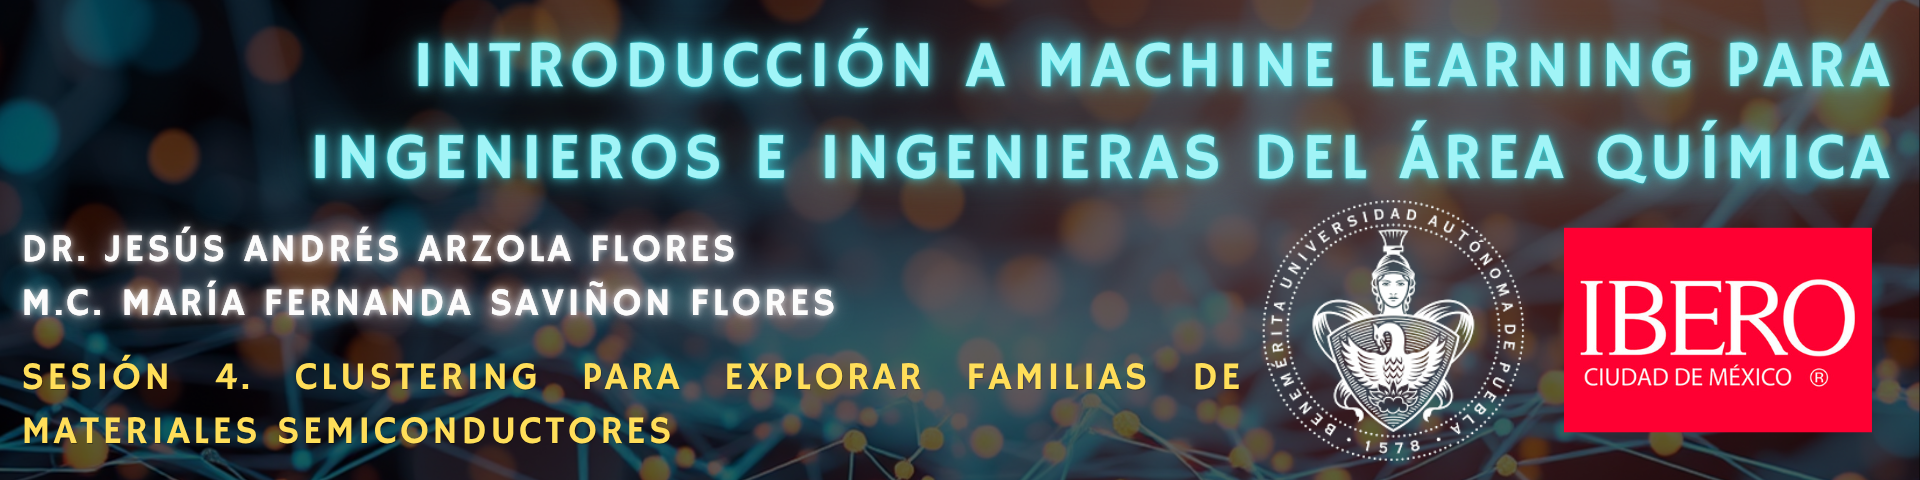

# Sesión 4. Clustering para explorar familias de materiales semiconductores

**Curso:** Machine Learning introductorio para ingenieros del área química  
**Metodología:** Aprendizaje Basado en Casos  
**Duración:** 2 horas  
**Entorno:** Google Colab  

---

## Instrucción inicial

Antes de comenzar, guarda una copia de este notebook en tu Google Drive:

**Archivo → Guardar una copia en Drive**

Trabajarás sobre tu propia copia del archivo.


## 1. Contexto del caso

Un grupo de investigación en materiales desea explorar una base de datos real de **materiales inorgánicos**. El propósito es identificar grupos o familias de materiales con características similares que puedan orientar el diseño de nuevos candidatos para aplicaciones como:

- semiconductores;
- fotocatálisis;
- sensores;
- recubrimientos funcionales;
- materiales para dispositivos energéticos;
- materiales optoelectrónicos;
- materiales para conversión y almacenamiento de energía.

En las sesiones anteriores se trabajó con modelos supervisados, donde el conjunto de datos tenía una variable objetivo que se quería predecir o clasificar. Por ejemplo:

| Tipo de problema | Ejemplo | Variable objetivo |
|---|---|---|
| Regresión | Predicción de solubilidad acuosa | Solubilidad |
| Clasificación | Calidad de agua | Potable / no potable |

En esta sesión el enfoque será diferente. Usaremos una técnica de **aprendizaje no supervisado**, específicamente **clustering**. Esto significa que no queremos predecir una etiqueta conocida, sino descubrir si los materiales pueden organizarse en grupos con características similares.

El conjunto de datos contiene fórmulas químicas y valores experimentales de **brecha de banda** o **band gap**. Esta propiedad es importante porque ayuda a distinguir materiales con comportamiento conductor, semiconductor o aislante, y es clave en aplicaciones relacionadas con absorción de luz, transporte electrónico y diseño de dispositivos.

---

## Situación problema

Imaginemos que un equipo de investigación tiene una base de datos con miles de materiales inorgánicos. El equipo desea hacer una exploración inicial para responder preguntas como:

- ¿existen grupos de materiales con band gap parecido?
- ¿los materiales con oxígeno forman grupos diferentes?
- ¿la fracción metálica se relaciona con ciertos rangos de band gap?
- ¿podemos seleccionar materiales diversos para analizarlos después con métodos más detallados?
- ¿qué materiales podrían ser candidatos preliminares para aplicaciones semiconductoras?

En una investigación real, el diseño de materiales requiere considerar muchas propiedades adicionales, por ejemplo:

- estabilidad termodinámica;
- estructura cristalina;
- disponibilidad de elementos;
- toxicidad;
- costo;
- facilidad de síntesis;
- propiedades ópticas;
- propiedades eléctricas;
- resistencia química;
- desempeño bajo condiciones reales de operación.

Sin embargo, por ahora conviene iniciar con variables simples y fáciles de interpretar. Por eso usaremos pocas variables:

- número de elementos en la fórmula;
- fracción de oxígeno;
- fracción de elementos metálicos;
- band gap experimental.

La idea no es encontrar inmediatamente “el mejor material”, sino aprender cómo el clustering puede ayudar a **organizar datos**, **identificar patrones** y **plantear hipótesis** para estudios posteriores.

---

## Enfoque de la sesión

En esta sesión se seguirá el siguiente flujo:

1. Cargar un conjunto de datos real de materiales.
2. Revisar la variable band gap.
3. Calcular variables simples a partir de la fórmula química.
4. Escalar las variables.
5. Usar el método del codo para explorar posibles valores de $k$.
6. Aplicar K-means para agrupar materiales.
7. Evaluar la calidad del clustering con métricas internas.
8. Interpretar los perfiles de los clusters.
9. Seleccionar candidatos diversos para diseño exploratorio.

Este flujo es común en etapas iniciales de ciencia de datos aplicada a materiales: primero se exploran los datos, después se agrupan por similitud y finalmente se interpretan los grupos desde el conocimiento químico e ingenieril.

---

## Idea central

El clustering no sustituye la interpretación química. Más bien, funciona como una herramienta para apoyar la exploración.

En palabras simples:

> El clustering ayuda a ordenar materiales en familias con características similares, pero la interpretación final requiere conocimiento de química, materiales y del problema de aplicación.


## 2. Pregunta detonadora

**¿Podemos agrupar materiales reales por similitud química y electrónica para identificar familias útiles en el diseño de nuevos materiales?**


## 3. Objetivo de aprendizaje

Al finalizar la sesión, el participante será capaz de:

- Explicar qué es clustering.
- Cargar un dataset real de materiales.
- Transformar fórmulas químicas en variables simples.
- Escalar variables antes de aplicar K-means.
- Usar el método del codo para elegir un número tentativo de grupos.
- Aplicar K-means para agrupar materiales.
- Interpretar clusters usando propiedades originales.
- Seleccionar materiales candidatos a partir de los grupos identificados.


## 4. Conceptos básicos

### 4.1 ¿Qué es clustering?

El **clustering** es una técnica de aprendizaje no supervisado. Se usa cuando no tenemos una etiqueta de respuesta, pero queremos encontrar grupos naturales en los datos.

En un problema supervisado, el modelo aprende a partir de ejemplos con una respuesta conocida. Por ejemplo:

| Problema supervisado | Entrada | Salida conocida |
|---|---|---|
| Regresión | Descriptores moleculares | Solubilidad |
| Clasificación | Variables de calidad de agua | Potable / no potable |

En cambio, en clustering no partimos de una etiqueta conocida. El algoritmo analiza las variables disponibles y busca organizar las muestras en grupos.

En este caso:

| Elemento | Descripción |
|---|---|
| Observación | Un material |
| Dato principal | Fórmula química |
| Propiedad de interés | Band gap experimental |
| Objetivo | Agrupar materiales similares |
| Algoritmo | K-means |

El resultado del clustering no debe interpretarse como una verdad absoluta. Un cluster es una agrupación generada con base en las variables seleccionadas. Si cambiamos las variables, el método de escalamiento o el número de clusters, los grupos pueden cambiar.

Por eso, en ingeniería y ciencia de materiales, el clustering se utiliza como una herramienta de exploración, no como una decisión final.

---

### 4.2 ¿Qué es el band gap?

El **band gap** o **brecha de banda** es una propiedad electrónica de los materiales. Representa la diferencia de energía entre la **banda de valencia** y la **banda de conducción**.

De manera conceptual:

- la **banda de valencia** contiene electrones que están ligados al material;
- la **banda de conducción** contiene electrones que pueden moverse con mayor libertad y contribuir al transporte eléctrico;
- el **band gap** indica cuánta energía necesita un electrón para pasar de la banda de valencia a la banda de conducción.

La idea se puede expresar como:

$$
E_g = E_{\text{conducción}} - E_{\text{valencia}}
$$

donde:

- $E_g$ es el band gap;
- $E_{\text{conducción}}$ es la energía asociada al borde de la banda de conducción;
- $E_{\text{valencia}}$ es la energía asociada al borde de la banda de valencia.

El band gap se expresa comúnmente en **electronvolts**, abreviado como **eV**.

---

## Interpretación general del band gap

De forma aproximada, el band gap permite clasificar materiales según su comportamiento electrónico:

| Tipo de material | Band gap aproximado | Interpretación |
|---|---:|---|
| Conductor | Cercano a 0 eV | Los electrones pueden moverse con facilidad. |
| Semiconductor | Intermedio | Puede conducir bajo ciertas condiciones. |
| Aislante | Alto | Se requiere mucha energía para promover electrones a la banda de conducción. |

Esta clasificación es general. En la práctica, el comportamiento real también depende de la estructura cristalina, defectos, dopaje, temperatura, pureza y condiciones de medición.

---

## Ejemplos cualitativos

| Material | Interpretación general |
|---|---|
| Metales | Band gap muy pequeño o inexistente. |
| Silicio | Semiconductor ampliamente usado en electrónica. |
| TiO$_2$ | Semiconductor usado en fotocatálisis y recubrimientos. |
| Óxidos aislantes | Suelen tener band gaps altos. |

En materiales semiconductores, el valor del band gap es crucial porque determina qué tipo de energía puede absorber el material y cómo puede participar en procesos electrónicos u ópticos.

---

## ¿Cómo se puede obtener el band gap?

El band gap puede obtenerse de diferentes formas.

### 1. Medición experimental

Algunos métodos experimentales comunes son:

- espectroscopía UV-Vis;
- reflectancia difusa;
- fotoluminiscencia;
- medidas eléctricas;
- espectroscopía de absorción óptica.

En análisis óptico, una forma común de estimar el band gap es mediante gráficos tipo **Tauc**, donde se relaciona la absorción óptica con la energía del fotón. La forma exacta depende de si la transición es directa o indirecta.

De manera simplificada, para una transición óptica se puede trabajar con expresiones del tipo:

$$
(\alpha h\nu)^m = A(h\nu - E_g)
$$

donde:

- $\alpha$ es el coeficiente de absorción;
- $h\nu$ es la energía del fotón;
- $A$ es una constante;
- $E_g$ es el band gap;
- $m$ depende del tipo de transición electrónica.

### 2. Cálculo computacional

También puede estimarse mediante métodos computacionales, por ejemplo:

- teoría del funcional de la densidad, DFT;
- métodos híbridos;
- modelos de machine learning;
- bases de datos computacionales de materiales.

En esta sesión usaremos valores experimentales disponibles en el conjunto de datos `matbench_expt_gap`.

---

## Utilidad del band gap

El band gap es útil porque orienta posibles aplicaciones. Por ejemplo:

| Rango o comportamiento | Posible aplicación |
|---|---|
| Band gap bajo | Electrónica, conductores, semimetales |
| Band gap intermedio | Semiconductores, celdas solares, fotocatálisis |
| Band gap alto | Aislantes, recubrimientos dieléctricos, barreras eléctricas |

Un band gap entre aproximadamente 1.5 y 3.0 eV suele discutirse en aplicaciones semiconductoras y fotoactivas, aunque la utilidad real depende de muchos otros factores.

---

## Relación con esta práctica

En esta práctica, el band gap no se usará para predecir una propiedad, sino como una variable que ayudará a agrupar materiales.

Por ejemplo, dos materiales podrían quedar en el mismo cluster si tienen:

- número de elementos similar;
- fracción de oxígeno similar;
- fracción metálica similar;
- band gap experimental similar.

Así, el clustering puede ayudar a identificar familias de materiales con propiedades relacionadas.

---

## Precaución

El band gap por sí solo no basta para decidir si un material es útil. Para una aplicación real también se necesitarían otras propiedades, como:

- estabilidad;
- disponibilidad de elementos;
- toxicidad;
- costo;
- estructura cristalina;
- movilidad de carga;
- eficiencia bajo condiciones reales.

Por lo tanto, en esta sesión el band gap se usará como una variable de exploración, no como criterio definitivo de selección.


## 5. Conjunto de datos utilizado

Usaremos el dataset **matbench_expt_gap**, disponible mediante la biblioteca `matminer`.

Este dataset contiene materiales inorgánicos con:

- `composition`: fórmula química,
- `gap expt`: band gap experimental en eV.

El conjunto contiene aproximadamente **4,604 materiales** y forma parte de Matbench.

### Referencias sugeridas

1. Zhuo, Y., Mansouri Tehrani, A., y Brgoch, J. (2018). *Predicting the Band Gaps of Inorganic Solids by Machine Learning*. The Journal of Physical Chemistry Letters, 9(7), 1668–1673. https://doi.org/10.1021/acs.jpclett.8b00124  
2. Dunn, A., Wang, Q., Ganose, A., Dopp, D., y Jain, A. (2020). *Benchmarking materials property prediction methods: the Matbench test set and Automatminer reference algorithm*. npj Computational Materials, 6, 138. https://doi.org/10.1038/s41524-020-00406-3  
3. Jain, A. K. (2010). *Data clustering: 50 years beyond K-means*. Pattern Recognition Letters, 31(8), 651–666. https://doi.org/10.1016/j.patrec.2009.09.011  

### Flujo de la sesión

**fórmula química → variables simples → escalamiento → clustering → interpretación**


## 6. Instalación de bibliotecas

Instalaremos `matminer` para cargar el conjunto de datos y `pymatgen` para interpretar fórmulas químicas.

Esta celda puede tardar un poco la primera vez.


**Código de referencia para la siguiente celda:**

```python
!pip -q install matminer pymatgen
```

In [23]:
#Escribir el código aquí

## 7. Carga de librerías

**Código de referencia para la siguiente celda:**

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matminer.datasets import load_dataset
from pymatgen.core import Composition, Element

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

np.random.seed(42)
```

In [24]:
#Escribir el código aquí

## 8. Carga del dataset real

Cargaremos el dataset `matbench_expt_gap`.


**Código de referencia para la siguiente celda:**

```python
df = load_dataset("matbench_expt_gap")

df.head()
```

In [25]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
print("Número de materiales:", df.shape[0])
print("Número de columnas:", df.shape[1])
df.columns
```

In [26]:
#Escribir el código aquí

## 9. Revisión de la variable band gap

La columna `gap expt` contiene el band gap experimental en eV.


**Código de referencia para la siguiente celda:**

```python
df['gap expt'].describe()
```

In [27]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
plt.figure(figsize=(7, 5))
plt.hist(df['gap expt'], bins=40)
plt.xlabel('Band gap experimental (eV)')
plt.ylabel('Frecuencia')
plt.title('Distribución de band gap experimental')
plt.grid(True, alpha=0.3)
plt.show()
```

In [28]:
#Escribir el código aquí

## 10. Variables simples a partir de la fórmula química

Calcularemos solo tres variables químicas:

| Variable | Significado |
|---|---|
| `n_elementos` | Número de elementos diferentes en la fórmula |
| `fraccion_oxigeno` | Proporción de oxígeno en la fórmula |
| `fraccion_metalica` | Proporción de átomos metálicos en la fórmula |

Ejemplo:

Para `TiO2`:

- tiene 2 elementos: Ti y O,
- de 3 átomos totales, 2 son oxígeno,
- la fracción de oxígeno es 2/3,
- Ti es metal, por lo que la fracción metálica es 1/3.

Estas variables son simples, pero suficientes para una primera práctica de clustering.


## 11. Ejemplo con una fórmula química

Antes de calcular variables para todos los materiales, revisemos un ejemplo con `TiO2`.


**Código de referencia para la siguiente celda:**

```python
formula = "TiO2"

comp = Composition(formula)
elementos = comp.get_el_amt_dict()
total_atomos = sum(elementos.values())

print("Fórmula:", formula)
print("Elementos y cantidades:", elementos)
print("Total de átomos:", total_atomos)
print("Número de elementos:", len(elementos))
print("Fracción de oxígeno:", elementos.get("O", 0) / total_atomos)

fraccion_metalica = 0

for simbolo, cantidad in elementos.items():
    if Element(simbolo).is_metal:
        fraccion_metalica += cantidad

fraccion_metalica = fraccion_metalica / total_atomos

print("Fracción metálica:", fraccion_metalica)
```

In [29]:
#Escribir el código aquí

## 12. Cálculo de variables simples para todo el conjunto de datos

Ahora aplicaremos la misma lógica a todas las fórmulas del conjunto de datos.

Para que el código sea más claro, usaremos una función pequeña que recibe una fórmula y devuelve las tres variables.


**Código de referencia para la siguiente celda:**

```python
def calcular_variables_simples(formula):
    comp = Composition(str(formula))
    elementos = comp.get_el_amt_dict()
    total_atomos = sum(elementos.values())

    n_elementos = len(elementos)
    fraccion_oxigeno = elementos.get("O", 0) / total_atomos

    cantidad_metales = 0
    for simbolo, cantidad in elementos.items():
        if Element(simbolo).is_metal:
            cantidad_metales += cantidad

    fraccion_metalica = cantidad_metales / total_atomos

    return pd.Series({
        "n_elementos": n_elementos,
        "fraccion_oxigeno": fraccion_oxigeno,
        "fraccion_metalica": fraccion_metalica
    })
```

In [30]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
variables_formula = df["composition"].apply(calcular_variables_simples)

df_materiales = pd.concat([
    df[["composition", "gap expt"]],
    variables_formula
], axis=1)

df_materiales.head()
```

In [31]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
df_materiales.describe().round(3)
```

In [32]:
#Escribir el código aquí

## 13. Exploración visual

Antes del clustering, observemos algunas relaciones sencillas.


**Código de referencia para la siguiente celda:**

```python
plt.figure(figsize=(7, 5))
plt.scatter(df_materiales["fraccion_oxigeno"], df_materiales["gap expt"], alpha=0.5)
plt.xlabel("Fracción de oxígeno")
plt.ylabel("Band gap experimental (eV)")
plt.title("Fracción de oxígeno vs. band gap")
plt.grid(True, alpha=0.3)
plt.show()
```

In [33]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
plt.figure(figsize=(7, 5))
plt.scatter(df_materiales["fraccion_metalica"], df_materiales["gap expt"], alpha=0.5)
plt.xlabel("Fracción metálica")
plt.ylabel("Band gap experimental (eV)")
plt.title("Fracción metálica vs. band gap")
plt.grid(True, alpha=0.3)
plt.show()
```

In [34]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
plt.figure(figsize=(7, 5))
plt.scatter(df_materiales["n_elementos"], df_materiales["gap expt"], alpha=0.5)
plt.xlabel("Número de elementos")
plt.ylabel("Band gap experimental (eV)")
plt.title("Número de elementos vs. band gap")
plt.grid(True, alpha=0.3)
plt.show()
```

In [35]:
#Escribir el código aquí

## 14. Actividad 1. Interpretación previa

Responde:

1. ¿Los materiales con mayor fracción de oxígeno parecen tener mayor o menor band gap?
2. ¿La fracción metálica muestra alguna tendencia visible?
3. ¿Qué materiales podrían ser más simples de sintetizar: con pocos o muchos elementos?
4. ¿Qué información adicional necesitarías para diseñar un material real?
5. ¿Por qué el clustering puede ser útil antes de seleccionar candidatos?

**Respuesta:**








## 15. Selección de variables para clustering

Usaremos cuatro variables:

- `gap expt`,
- `n_elementos`,
- `fraccion_oxigeno`,
- `fraccion_metalica`.



**Código de referencia para la siguiente celda:**

```python
variables = ["gap expt", "n_elementos", "fraccion_oxigeno", "fraccion_metalica"]

X = df_materiales[variables]

X.head()
```

In [36]:
#Escribir el código aquí

## 16. Escalamiento de variables

Como las variables están en escalas diferentes, debemos escalarlas.

Por ejemplo:

- `gap expt` puede ir de 0 a más de 10 eV,
- `fraccion_oxigeno` va de 0 a 1,
- `n_elementos` es un conteo.

El escalamiento evita que una variable domine artificialmente el clustering.


**Código de referencia para la siguiente celda:**

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=variables)
X_scaled_df.head()
```

In [37]:
#Escribir el código aquí

## 17. Método del codo

Antes de aplicar K-means necesitamos elegir el número de clusters, representado por $k$.

El valor de $k$ indica cuántos grupos queremos formar. Por ejemplo:

| Valor de $k$ | Interpretación                                       |
| -----------: | ---------------------------------------------------- |
|        $k=2$ | El algoritmo divide los materiales en dos grupos.    |
|        $k=3$ | El algoritmo divide los materiales en tres grupos.   |
|        $k=4$ | El algoritmo divide los materiales en cuatro grupos. |

El problema es que, en aprendizaje no supervisado, normalmente no sabemos de antemano cuántos clusters existen. A diferencia de la clasificación supervisada, aquí no tenemos una columna de respuesta como “tipo de material”, “material útil” o “material no útil”. El algoritmo solo observa las variables numéricas y busca patrones de similitud.

Por eso, elegir $k$ es una decisión importante.

Si usamos un valor de $k$ demasiado pequeño, podemos juntar materiales que en realidad tienen propiedades muy diferentes. Si usamos un valor de $k$ demasiado grande, podemos formar muchos grupos pequeños que tal vez sean difíciles de interpretar desde el punto de vista químico o ingenieril.

---

## ¿Qué significa elegir $k$?

Supongamos que estamos analizando materiales usando propiedades como:

* energía de formación;
* volumen por átomo;
* densidad;
* número de elementos;
* band gap.

Si elegimos:

$$
k=2
$$

el algoritmo intentará dividir los materiales en dos grupos. Por ejemplo, podría separar materiales con band gap bajo y materiales con band gap alto.

Si elegimos:

$$
k=3
$$

podría formar tres grupos, por ejemplo:

* materiales con band gap bajo;
* materiales con band gap intermedio;
* materiales con band gap alto.

Si elegimos:

$$
k=5
$$

el algoritmo buscará cinco grupos. Esto podría revelar patrones más específicos, pero también puede dificultar la interpretación.

Por lo tanto, elegir $k$ no es solo una decisión matemática. También debe tener sentido desde el problema de ingeniería o ciencia de materiales.

---

## Idea general del método del codo

K-means busca formar clusters compactos. Un cluster compacto es un grupo donde los puntos están cerca de su centroide.

El **centroide** es el punto promedio de un cluster. Representa el centro geométrico del grupo.

---

## ¿Cómo se calcula el centroide?

El centroide de un cluster se calcula obteniendo el promedio de cada variable para todas las muestras que pertenecen a ese cluster.

Si un cluster $C_r$ tiene $m$ muestras, su centroide se calcula como:

$$
\mu_r=\frac{1}{m}\sum_{i=1}^{m}x_i
$$

donde:

* $\mu_r$ es el centroide del cluster $r$;
* $m$ es el número de muestras dentro del cluster;
* $x_i$ representa cada muestra del cluster;
* la suma se realiza sobre todas las muestras que pertenecen a ese cluster.

Si cada muestra tiene varias variables, el centroide se calcula variable por variable.

Por ejemplo, si usamos dos propiedades de materiales:

$$
x_i=[\text{band gap},\text{densidad}]
$$

entonces el centroide tendrá también dos componentes:

$$
\mu_r=[
\mu_{\text{band gap}},
\mu_{\text{densidad}}
]
$$

Cada componente se calcula como un promedio.

Supongamos que un cluster contiene tres materiales:

| Material | Band gap | Densidad |
| -------- | -------: | -------: |
| A        |      1.0 |      5.0 |
| B        |      1.2 |      5.2 |
| C        |      0.8 |      4.8 |

El centroide se calcula promediando cada columna.

Para band gap:

$$
\mu_{\text{band gap}}=\frac{1.0+1.2+0.8}{3}
$$

$$
\mu_{\text{band gap}}=1.0
$$

Para densidad:

$$
\mu_{\text{densidad}}=\frac{5.0+5.2+4.8}{3}
$$

$$
\mu_{\text{densidad}}=5.0
$$

Por lo tanto, el centroide del cluster es:

$$
\mu_r=[1.0,5.0]
$$

Esto significa que el centroide representa el punto promedio del grupo. No necesariamente corresponde a un material real del conjunto de datos, sino que funciona como una referencia matemática para medir qué tan cerca están los materiales de ese cluster.

En K-means, este cálculo se repite varias veces. Primero se asignan los materiales al centroide más cercano, después se recalculan los centroides con los materiales asignados, y el proceso continúa hasta que los centroides cambian muy poco o las asignaciones se estabilizan.

---

## Inercia o WCSS

Para medir qué tan compactos son los clusters se usa una cantidad llamada **inercia**, también conocida como:

* WCSS, por sus siglas en inglés: *Within-Cluster Sum of Squares*;
* suma de cuadrados dentro de los clusters;
* suma de distancias cuadráticas internas.

La inercia se define como:

$$
\text{Inercia} =
\sum_{r=1}^{k}
\sum_{x_i \in C_r}
\left|x_i-\mu_r\right|^2
$$

donde:

* $k$ es el número de clusters;
* $C_r$ es el cluster $r$;
* $x_i$ es una muestra asignada al cluster $C_r$;
* $\mu_r$ es el centroide del cluster $C_r$;
* $\left|x_i-\mu_r\right|^2$ es la distancia cuadrática entre una muestra y el centroide de su cluster.

En palabras simples:

> La inercia mide qué tan lejos están los puntos de sus centroides. Mientras menor sea la inercia, más compactos son los clusters.

---

## Interpretación de la fórmula de inercia

La fórmula puede parecer complicada, pero se puede entender paso a paso.

Primero, para cada cluster, K-means calcula la distancia entre cada punto y el centroide de su cluster.

Después, eleva cada distancia al cuadrado.

Finalmente, suma todas esas distancias cuadráticas.

Por ejemplo, si un cluster tiene tres materiales y sus distancias al centroide son:

$$
d_1=1.0
$$

$$
d_2=2.0
$$

$$
d_3=3.0
$$

entonces la contribución de ese cluster a la inercia es:

$$
d_1^2+d_2^2+d_3^2
$$

$$
=1.0^2+2.0^2+3.0^2
$$

$$
=1+4+9
$$

$$
=14
$$

Si otro cluster tiene distancias más pequeñas, por ejemplo:

$$
d_1=0.5,\quad d_2=0.8,\quad d_3=1.0
$$

su contribución sería:

$$
0.5^2+0.8^2+1.0^2
$$

$$
=0.25+0.64+1.00
$$

$$
=1.89
$$

Este segundo cluster es más compacto, porque sus puntos están más cerca de su centroide.

---

## Ejemplo sencillo con materiales

Imaginemos que queremos agrupar materiales usando solo dos propiedades:

* band gap;
* densidad.

Un material puede representarse como:

$$
x_i=[\text{band gap},\text{densidad}]
$$

Supongamos que un cluster tiene estos tres materiales:

| Material | Band gap | Densidad |
| -------- | -------: | -------: |
| A        |      1.0 |      5.0 |
| B        |      1.2 |      5.2 |
| C        |      0.8 |      4.8 |

El centroide del cluster se calcula como el promedio de cada variable.

Para band gap:

$$
\mu_{\text{band gap}}=\frac{1.0+1.2+0.8}{3}
$$

$$
\mu_{\text{band gap}}=1.0
$$

Para densidad:

$$
\mu_{\text{densidad}}=\frac{5.0+5.2+4.8}{3}
$$

$$
\mu_{\text{densidad}}=5.0
$$

Entonces, el centroide es:

$$
\mu=[1.0,5.0]
$$

Ahora calculamos la distancia de cada material al centroide.

Para el material A:

$$
d(A,\mu)=\sqrt{(1.0-1.0)^2+(5.0-5.0)^2}
$$

$$
d(A,\mu)=0
$$

Para el material B:

$$
d(B,\mu)=\sqrt{(1.2-1.0)^2+(5.2-5.0)^2}
$$

$$
d(B,\mu)=\sqrt{0.2^2+0.2^2}
$$

$$
d(B,\mu)=\sqrt{0.04+0.04}
$$

$$
d(B,\mu)=\sqrt{0.08}
$$

$$
d(B,\mu)\approx 0.283
$$

Para el material C:

$$
d(C,\mu)=\sqrt{(0.8-1.0)^2+(4.8-5.0)^2}
$$

$$
d(C,\mu)=\sqrt{(-0.2)^2+(-0.2)^2}
$$

$$
d(C,\mu)=\sqrt{0.04+0.04}
$$

$$
d(C,\mu)\approx 0.283
$$

La contribución de este cluster a la inercia sería:

$$
0^2+0.283^2+0.283^2
$$

$$
=0+0.08+0.08
$$

$$
=0.16
$$

Este valor es bajo, por lo que el cluster es compacto.

---

## ¿Qué ocurre cuando aumenta $k$?

Cuando aumentamos el número de clusters, la inercia casi siempre disminuye. Esto ocurre porque cada cluster puede representar una región más pequeña de los datos.

Por ejemplo:

| Número de clusters | Interpretación                                                   |
| -----------------: | ---------------------------------------------------------------- |
|              $k=1$ | Todos los materiales están en un solo grupo. La inercia es alta. |
|              $k=2$ | Los materiales se dividen en dos grupos. La inercia baja.        |
|              $k=3$ | Los grupos son más específicos. La inercia baja más.             |
|              $k=8$ | Hay más grupos. La inercia baja todavía más.                     |

En el caso extremo, si cada material fuera su propio cluster, la distancia de cada punto a su centroide sería cero. Por lo tanto, la inercia sería casi nula. Pero eso no tendría sentido práctico, porque no estaríamos agrupando materiales, sino asignando un grupo individual a cada muestra.

Por eso, el objetivo no es elegir el valor de $k$ que dé la menor inercia absoluta, sino encontrar un punto de equilibrio.

---

## Ejemplo conceptual: reducción de la inercia

Supongamos que probamos diferentes valores de $k$ y obtenemos:

| $k$ | Inercia |
| --: | ------: |
|   1 |    1000 |
|   2 |     520 |
|   3 |     310 |
|   4 |     250 |
|   5 |     220 |
|   6 |     205 |
|   7 |     195 |
|   8 |     188 |

La inercia siempre disminuye, pero no disminuye con la misma intensidad.

Podemos calcular cuánto baja la inercia al aumentar $k$.

| Cambio        | Reducción de inercia |
| ------------- | -------------------: |
| $k=1$ a $k=2$ |       $1000-520=480$ |
| $k=2$ a $k=3$ |        $520-310=210$ |
| $k=3$ a $k=4$ |         $310-250=60$ |
| $k=4$ a $k=5$ |         $250-220=30$ |
| $k=5$ a $k=6$ |         $220-205=15$ |
| $k=6$ a $k=7$ |         $205-195=10$ |
| $k=7$ a $k=8$ |          $195-188=7$ |

Al inicio, la reducción es grande. Después, la reducción se vuelve cada vez menor.

Esto sugiere que los primeros clusters capturan una parte importante de la estructura de los datos, pero después agregar más clusters aporta menos información.

---

## ¿Dónde está el “codo”?

El método del codo consiste en graficar:

$$
k \quad \text{vs.} \quad \text{inercia}
$$

Al inicio, al aumentar $k$, la inercia suele disminuir mucho. Después llega un punto donde agregar más clusters ya no reduce tanto la inercia. Ese punto se parece visualmente a un “codo”.

Ese codo representa un posible equilibrio entre:

* tener clusters compactos;
* no usar demasiados clusters;
* mantener una interpretación sencilla;
* evitar dividir artificialmente los datos en demasiados grupos.

En el ejemplo anterior, el codo podría estar alrededor de:

$$
k=3
$$

o:

$$
k=4
$$

La decisión final dependerá de la interpretación del problema.

---

## Interpretación visual del codo

Si graficamos los valores del ejemplo, la curva tendría una forma parecida a esta:

| $k$ | Inercia |
| --: | ------: |
|   1 |    1000 |
|   2 |     520 |
|   3 |     310 |
|   4 |     250 |
|   5 |     220 |
|   6 |     205 |
|   7 |     195 |
|   8 |     188 |

La caída de $k=1$ a $k=3$ es muy pronunciada. Después de $k=3$ o $k=4$, la curva empieza a aplanarse.

En palabras simples:

> Antes del codo, agregar clusters mejora mucho la compactación. Después del codo, agregar clusters mejora poco y puede complicar la interpretación.

---

## Ejemplo aplicado a materiales

Supongamos que queremos agrupar materiales para identificar candidatos con propiedades similares.

Si usamos:

$$
k=2
$$

tal vez obtenemos dos grupos muy generales:

* materiales con band gap bajo;
* materiales con band gap alto.

Si usamos:

$$
k=3
$$

podríamos obtener algo más útil:

* materiales con bajo band gap, posibles conductores o semiconductores estrechos;
* materiales con band gap intermedio, posibles semiconductores;
* materiales con alto band gap, posibles aislantes.

Si usamos:

$$
k=6
$$

podríamos obtener grupos más específicos, pero quizás difíciles de describir:

* grupo 1: bajo band gap y baja densidad;
* grupo 2: bajo band gap y alta densidad;
* grupo 3: band gap intermedio y baja energía de formación;
* grupo 4: band gap intermedio y alta densidad;
* grupo 5: alto band gap y baja densidad;
* grupo 6: alto band gap y alto volumen atómico.

Aunque $k=6$ puede reducir más la inercia, puede ser menos práctico si el objetivo de la sesión es interpretar patrones generales.

---

## ¿Por qué el método del codo no da una respuesta exacta?

El método del codo es una herramienta exploratoria. No siempre existe un codo claramente visible.

Pueden ocurrir varios casos:

### Caso 1: codo claro

La curva baja rápido y luego se aplana claramente. En este caso, elegir $k$ es relativamente sencillo.

### Caso 2: codo ambiguo

La curva baja de forma gradual, sin un punto evidente. En este caso, podrían ser razonables varios valores de $k$.

### Caso 3: no hay codo

La inercia disminuye de manera casi lineal. Esto puede indicar que los datos no tienen una estructura de clusters bien definida para K-means.

Por eso, el método del codo no debe usarse de forma aislada.

---

## Limitaciones del método del codo

El método del codo es útil, pero tiene limitaciones importantes:

* depende de una inspección visual;
* a veces el codo no es evidente;
* diferentes personas podrían elegir diferentes valores de $k$;
* solo considera compactación interna;
* no evalúa directamente si los clusters están bien separados entre sí;
* no garantiza que los clusters tengan sentido químico o físico;
* puede verse afectado por escalamiento, variables irrelevantes o valores atípicos.

En ciencia de materiales, no basta con que una métrica sugiera cierto $k$. También debemos preguntarnos si los clusters tienen sentido químico y si ayudan a responder el problema.

Por ejemplo, si un clustering separa los materiales en grupos que no muestran diferencias claras en band gap, estabilidad o composición, entonces tal vez no sea útil, aunque la métrica matemática sea aceptable.

---

## Otros métodos para elegir el número de clusters

Además del método del codo, se pueden usar otros enfoques.

| Método                          | Idea general                                                               | Interpretación                                                                  |
| ------------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| Gráfica de silueta              | Evalúa cohesión dentro del cluster y separación respecto a otros clusters. | Valores altos indican clusters compactos y bien separados.                      |
| Coeficiente de silueta promedio | Resume la calidad del clustering en un valor entre -1 y 1.                 | Se suele preferir el $k$ con mayor silueta promedio.                            |
| Índice Calinski-Harabasz        | Compara separación entre clusters contra dispersión dentro de clusters.    | Valores mayores suelen indicar mejor separación.                                |
| Índice Davies-Bouldin           | Evalúa similitud entre clusters.                                           | Valores menores suelen indicar mejor clustering.                                |
| Gap statistic                   | Compara la estructura observada contra datos de referencia sin estructura. | Busca un $k$ donde los datos reales estén mejor agrupados que datos aleatorios. |
| Interpretación experta          | Revisa si los clusters tienen sentido químico o ingenieril.                | Es fundamental en ciencia de materiales.                                        |

---

## Gráfica de silueta

La silueta mide qué tan bien asignado está cada punto a su cluster.

Para una muestra $i$, se definen dos cantidades:

$$
a(i)
$$

y:

$$
b(i)
$$

donde:

* $a(i)$ es la distancia promedio entre la muestra $i$ y las demás muestras de su mismo cluster;
* $b(i)$ es la menor distancia promedio entre la muestra $i$ y las muestras de otro cluster cercano.

El coeficiente de silueta se calcula como:

$$
s(i)=\frac{b(i)-a(i)}{\max{a(i),b(i)}}
$$

El valor de $s(i)$ puede estar entre -1 y 1.

| Valor de silueta | Interpretación                                          |
| ---------------: | ------------------------------------------------------- |
|      Cercano a 1 | La muestra está bien asignada a su cluster.             |
|      Cercano a 0 | La muestra está en una zona de frontera entre clusters. |
|         Negativo | La muestra podría estar asignada al cluster equivocado. |

El coeficiente de silueta promedio se puede calcular para varios valores de $k$. Una estrategia común es elegir el valor de $k$ que produce una silueta promedio alta.

---

## Ejemplo de comparación entre método del codo y silueta

Supongamos que obtenemos:

| $k$ | Inercia | Silueta promedio |
| --: | ------: | ---------------: |
|   2 |     520 |             0.42 |
|   3 |     310 |             0.55 |
|   4 |     250 |             0.49 |
|   5 |     220 |             0.44 |

El método del codo podría sugerir:

$$
k=3
$$

o:

$$
k=4
$$

Pero la silueta promedio es mayor para:

$$
k=3
$$

Entonces, en este caso, $k=3$ podría ser una decisión más sólida.

---

## Importancia de la interpretación química

En ciencia de materiales, el valor de $k$ no debe elegirse solo porque una gráfica o métrica lo sugiera. También debemos revisar si los clusters tienen sentido.

Por ejemplo, después de agrupar los materiales, podemos preguntarnos:

* ¿Los clusters separan materiales con band gap bajo, intermedio y alto?
* ¿Hay grupos con energía de formación baja, que podrían ser más estables?
* ¿Los materiales de un mismo cluster tienen composiciones químicas parecidas?
* ¿Algún cluster contiene candidatos interesantes para aplicaciones electrónicas, fotovoltaicas o catalíticas?
* ¿Los clusters ayudan a generar hipótesis o seleccionar materiales para análisis posterior?

Si el valor de $k$ permite responder mejor estas preguntas, entonces tiene mayor utilidad desde la perspectiva ingenieril.

---

El método del codo es una herramienta sencilla para elegir un número inicial de clusters en K-means. Se basa en analizar cómo disminuye la inercia al aumentar $k$.

La idea principal es encontrar un punto donde agregar más clusters ya no produzca una mejora importante en la compactación.

Sin embargo, el método del codo no da una respuesta definitiva. Debe complementarse con otras métricas, como la silueta, Calinski-Harabasz o Davies-Bouldin, y con la interpretación química o ingenieril de los clusters.

En esta sesión usaremos el método del codo como primera guía y después calcularemos métricas internas de calidad del clustering.



**Código de referencia para la siguiente celda:**

```python
inercias = []

for k in range(1, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 9), inercias, marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True, alpha=0.3)
plt.show()
```

In [38]:
#Escribir el código aquí

## 17.1 Complemento: gráfica de silueta promedio

Además del método del codo, podemos calcular el **coeficiente de silueta promedio** para diferentes valores de $k$.

El método del codo usa la inercia para evaluar qué tan compactos son los clusters. Sin embargo, la inercia casi siempre disminuye cuando aumentamos $k$, por lo que a veces no es suficiente para decidir claramente el número de clusters.

Por eso, una métrica complementaria es el **coeficiente de silueta**.

La silueta compara dos ideas:

1. Qué tan cerca está una muestra de las muestras de su propio cluster.
2. Qué tan lejos está esa muestra del cluster vecino más cercano.

En otras palabras, la silueta mide si una muestra está bien integrada en su propio cluster o si se encuentra más cerca de otro cluster.

Para una muestra $i$, el coeficiente de silueta se define como:

$$
s(i)=\frac{b(i)-a(i)}{\max{a(i),b(i)}}
$$

donde:

* $a(i)$ es la distancia promedio de la muestra $i$ a las demás muestras de su propio cluster;
* $b(i)$ es la menor distancia promedio de la muestra $i$ hacia otro cluster;
* $s(i)$ es el valor de silueta para la muestra $i$.

La silueta puede tomar valores entre -1 y 1:

| Valor de silueta | Interpretación                                       |
| ---------------: | ---------------------------------------------------- |
|       Cerca de 1 | La muestra está bien asignada a su cluster.          |
|       Cerca de 0 | La muestra está cerca de la frontera entre clusters. |
|      Menor que 0 | La muestra podría estar mejor en otro cluster.       |

## ¿Qué significa $a(i)$?

El valor $a(i)$ mide qué tan cerca está una muestra de las demás muestras de su propio cluster.

Si $a(i)$ es pequeño, significa que la muestra está cerca de sus compañeras de cluster.

Si $a(i)$ es grande, significa que la muestra está lejos de las demás muestras de su propio cluster.

Por lo tanto:

* un valor pequeño de $a(i)$ es deseable;
* un valor grande de $a(i)$ puede indicar que la muestra no encaja bien en su cluster.

## ¿Qué significa $b(i)$?

El valor $b(i)$ mide qué tan lejos está una muestra del cluster vecino más cercano.

Para calcularlo, se obtiene la distancia promedio de la muestra hacia cada uno de los otros clusters. Después se elige la menor de esas distancias promedio.

Si $b(i)$ es grande, significa que la muestra está lejos de otros clusters.

Si $b(i)$ es pequeño, significa que la muestra está cerca de otro cluster.

Por lo tanto:

* un valor grande de $b(i)$ es deseable;
* un valor pequeño de $b(i)$ puede indicar que la muestra está cerca de la frontera entre clusters.

## Interpretación general de la fórmula

La fórmula es:

$$
s(i)=\frac{b(i)-a(i)}{\max{a(i),b(i)}}
$$

Si una muestra está bien asignada a su cluster, esperamos que:

$$
a(i) < b(i)
$$

Esto significa que la muestra está más cerca de su propio cluster que de otros clusters.

En ese caso:

$$
b(i)-a(i)>0
$$

y la silueta será positiva.

Si la muestra está muy bien asignada, $a(i)$ será mucho menor que $b(i)$ y el valor de silueta se acercará a 1.

Si la muestra está en una zona de frontera, entonces:

$$
a(i)\approx b(i)
$$

En ese caso:

$$
b(i)-a(i)\approx 0
$$

y la silueta estará cerca de 0.

Si la muestra parece estar más cerca de otro cluster que del suyo, entonces:

$$
a(i) > b(i)
$$

En ese caso:

$$
b(i)-a(i)<0
$$

y la silueta será negativa.

## Ejemplo paso a paso

Supongamos que tenemos seis materiales descritos por dos propiedades:

* band gap;
* densidad.

Para simplificar, ya fueron agrupados en dos clusters.

| Muestra | Band gap | Densidad | Cluster |
| ------- | -------: | -------: | ------- |
| A1      |      1.0 |      1.0 | A       |
| A2      |      2.0 |      1.0 | A       |
| A3      |      1.0 |      2.0 | A       |
| B1      |      5.0 |      5.0 | B       |
| B2      |      6.0 |      5.0 | B       |
| B3      |      5.0 |      6.0 | B       |

Queremos calcular el coeficiente de silueta de la muestra A1.

La muestra A1 pertenece al cluster A.

Sus coordenadas son:

$$
A1=(1,1)
$$

Las otras muestras de su mismo cluster son:

$$
A2=(2,1)
$$

$$
A3=(1,2)
$$

Las muestras del otro cluster son:

$$
B1=(5,5)
$$

$$
B2=(6,5)
$$

$$
B3=(5,6)
$$

## Paso 1. Calcular $a(i)$

Primero calculamos la distancia de A1 hacia las demás muestras de su propio cluster.

Usaremos la distancia euclidiana:

$$
d(x,y)=\sqrt{(x_1-y_1)^2+(x_2-y_2)^2}
$$

Distancia de A1 a A2:

$$
d(A1,A2)=\sqrt{(1-2)^2+(1-1)^2}
$$

$$
d(A1,A2)=\sqrt{(-1)^2+0^2}
$$

$$
d(A1,A2)=\sqrt{1}
$$

$$
d(A1,A2)=1
$$

Distancia de A1 a A3:

$$
d(A1,A3)=\sqrt{(1-1)^2+(1-2)^2}
$$

$$
d(A1,A3)=\sqrt{0^2+(-1)^2}
$$

$$
d(A1,A3)=\sqrt{1}
$$

$$
d(A1,A3)=1
$$

Ahora calculamos el promedio de esas distancias:

$$
a(A1)=\frac{d(A1,A2)+d(A1,A3)}{2}
$$

$$
a(A1)=\frac{1+1}{2}
$$

$$
a(A1)=1
$$

Esto significa que, en promedio, A1 está a una distancia de 1 respecto a las otras muestras de su propio cluster.

## Paso 2. Calcular $b(i)$

Ahora calculamos la distancia promedio de A1 hacia las muestras del otro cluster.

Distancia de A1 a B1:

$$
d(A1,B1)=\sqrt{(1-5)^2+(1-5)^2}
$$

$$
d(A1,B1)=\sqrt{(-4)^2+(-4)^2}
$$

$$
d(A1,B1)=\sqrt{16+16}
$$

$$
d(A1,B1)=\sqrt{32}
$$

$$
d(A1,B1)\approx 5.657
$$

Distancia de A1 a B2:

$$
d(A1,B2)=\sqrt{(1-6)^2+(1-5)^2}
$$

$$
d(A1,B2)=\sqrt{(-5)^2+(-4)^2}
$$

$$
d(A1,B2)=\sqrt{25+16}
$$

$$
d(A1,B2)=\sqrt{41}
$$

$$
d(A1,B2)\approx 6.403
$$

Distancia de A1 a B3:

$$
d(A1,B3)=\sqrt{(1-5)^2+(1-6)^2}
$$

$$
d(A1,B3)=\sqrt{(-4)^2+(-5)^2}
$$

$$
d(A1,B3)=\sqrt{16+25}
$$

$$
d(A1,B3)=\sqrt{41}
$$

$$
d(A1,B3)\approx 6.403
$$

Ahora calculamos el promedio de las distancias hacia el cluster B:

$$
b(A1)=\frac{d(A1,B1)+d(A1,B2)+d(A1,B3)}{3}
$$

$$
b(A1)=\frac{5.657+6.403+6.403}{3}
$$

$$
b(A1)=\frac{18.463}{3}
$$

$$
b(A1)\approx 6.154
$$

Como solo hay un cluster diferente al cluster A, ese promedio corresponde directamente a $b(A1)$.

Si hubiera más de dos clusters, tendríamos que calcular la distancia promedio de A1 hacia cada cluster externo y elegir la menor.

## Paso 3. Calcular la silueta de A1

Ya tenemos:

$$
a(A1)=1
$$

$$
b(A1)\approx 6.154
$$

Sustituimos en la fórmula:

$$
s(A1)=\frac{b(A1)-a(A1)}{\max{a(A1),b(A1)}}
$$

Como:

$$
b(A1)>a(A1)
$$

entonces:

$$
\max{a(A1),b(A1)}=6.154
$$

Por lo tanto:

$$
s(A1)=\frac{6.154-1}{6.154}
$$

$$
s(A1)=\frac{5.154}{6.154}
$$

$$
s(A1)\approx 0.837
$$

## Interpretación del resultado

El coeficiente de silueta de A1 es aproximadamente:

$$
s(A1)\approx 0.837
$$

Este valor está cerca de 1.

Eso significa que A1 está mucho más cerca de las muestras de su propio cluster que de las muestras del otro cluster.

Por lo tanto, A1 parece estar bien asignada al cluster A.

## Ejemplo de interpretación con otros valores

Supongamos tres posibles muestras con estos valores:

| Muestra   | $a(i)$ | $b(i)$ | $s(i)$ aproximado | Interpretación            |
| --------- | -----: | -----: | ----------------: | ------------------------- |
| Muestra 1 |    1.0 |    6.2 |              0.84 | Bien asignada             |
| Muestra 2 |    3.0 |    3.2 |              0.06 | Cerca de la frontera      |
| Muestra 3 |    4.0 |    2.5 |             -0.38 | Posiblemente mal asignada |

Para la muestra 1:

$$
a(i)<b(i)
$$

La muestra está más cerca de su propio cluster que de otros clusters. Por eso la silueta es positiva y alta.

Para la muestra 2:

$$
a(i)\approx b(i)
$$

La muestra está casi igual de cerca de su propio cluster que de otro cluster. Por eso la silueta está cerca de cero.

Para la muestra 3:

$$
a(i)>b(i)
$$

La muestra está más cerca de otro cluster que del suyo. Por eso la silueta es negativa.

## Silueta promedio

El coeficiente de silueta se calcula primero para cada muestra individual.

Después, se calcula el promedio de todas las siluetas:

$$
\bar{s}=\frac{1}{n}\sum_{i=1}^{n}s(i)
$$

donde:

* $\bar{s}$ es la silueta promedio;
* $n$ es el número total de muestras;
* $s(i)$ es la silueta de la muestra $i$.

Por ejemplo, supongamos que las seis muestras del ejemplo tienen los siguientes valores de silueta:

| Muestra | Silueta $s(i)$ |
| ------- | -------------: |
| A1      |          0.837 |
| A2      |          0.780 |
| A3      |          0.780 |
| B1      |          0.808 |
| B2      |          0.798 |
| B3      |          0.798 |

La silueta promedio sería:

$$
\bar{s}=
\frac{0.837+0.780+0.780+0.808+0.798+0.798}{6}
$$

$$
\bar{s}=
\frac{4.801}{6}
$$

$$
\bar{s}\approx 0.800
$$

Este valor indica que, en promedio, las muestras están bien agrupadas.

## Uso de la silueta para elegir $k$

Para elegir el número de clusters, se puede calcular la silueta promedio para diferentes valores de $k$.

Por ejemplo:

| Número de clusters $k$ | Silueta promedio |
| ---------------------: | ---------------: |
|                      2 |             0.62 |
|                      3 |             0.74 |
|                      4 |             0.69 |
|                      5 |             0.55 |

En este ejemplo, el valor más alto ocurre cuando:

$$
k=3
$$

Por lo tanto, desde el punto de vista de la silueta, $k=3$ sería una buena opción.

Sin embargo, esta decisión no debe tomarse solo con la métrica matemática. También debe revisarse si los clusters tienen sentido desde el punto de vista químico, físico o ingenieril.

Por ejemplo, en un análisis de materiales, no basta con que la silueta sea alta. También debemos preguntarnos:

* ¿Los grupos tienen propiedades químicas o físicas interpretables?
* ¿Los materiales dentro de un mismo cluster son realmente similares?
* ¿Los clusters separan familias de materiales relevantes?
* ¿El número de clusters es útil para el objetivo del análisis?

## Interpretación final

El coeficiente de silueta ayuda a evaluar la calidad de un agrupamiento.

Una silueta alta indica que las muestras están cerca de su propio cluster y lejos de otros clusters.

Una silueta cercana a cero indica que las muestras están en zonas de frontera.

Una silueta negativa indica que algunas muestras podrían estar mejor asignadas a otro cluster.

Por eso, la silueta promedio es una herramienta útil para comparar diferentes valores de $k$, pero siempre debe interpretarse junto con el conocimiento del problema.



**Código de referencia para la siguiente celda:**

```python
silhouette_scores = []

for k in range(2, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, etiquetas)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 9), silhouette_scores, marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Silueta promedio")
plt.title("Silueta promedio para diferentes valores de k")
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "k": range(2, 9),
    "silueta_promedio": silhouette_scores
})
```

In [39]:
#Escribir el código aquí

## 18. Clustering con K-means

Después de explorar el número de clusters mediante el método del codo, aplicaremos el algoritmo **K-means**.

K-means es uno de los algoritmos de clustering más utilizados porque es intuitivo, rápido y relativamente fácil de explicar.

La idea central es:

> K-means agrupa puntos de forma que cada muestra quede asignada al centroide más cercano.

Un **centroide** es el punto promedio de un cluster. No necesariamente corresponde a un material real; es una posición promedio en el espacio de variables.

---

## ¿Qué busca K-means?

K-means busca dividir los datos en $k$ clusters:

$$
C_1, C_2, C_3, \ldots, C_k
$$

de manera que los puntos dentro de cada cluster estén lo más cerca posible de su centroide.

La función objetivo de K-means puede escribirse como:

$$
\underset{C_1,\ldots,C_k}{\operatorname{min}}
\sum_{r=1}^{k}
\sum_{x_i \in C_r}
\left\|x_i-\mu_r\right\|^2
$$

donde:

- $k$ es el número de clusters;
- $C_r$ es el cluster $r$;
- $x_i$ es una muestra;
- $\mu_r$ es el centroide del cluster $r$;
- $\left\|x_i-\mu_r\right\|^2$ es la distancia cuadrática entre una muestra y el centroide de su cluster.

En palabras simples:

> K-means intenta minimizar la suma de las distancias cuadráticas entre cada muestra y el centroide de su cluster.

---

## ¿Cómo funciona el algoritmo?

K-means sigue un proceso iterativo:

1. Se elige el número de clusters $k$.
2. Se inicializan $k$ centroides.
3. Cada muestra se asigna al centroide más cercano.
4. Se recalcula cada centroide como el promedio de las muestras asignadas.
5. Se repiten los pasos 3 y 4 hasta que los centroides casi no cambien o se alcance un número máximo de iteraciones.

---

## Paso 1. Elegir el número de clusters

Supongamos que elegimos:

$$
k=4
$$

Esto significa que queremos agrupar los materiales en cuatro familias generales.

En esta práctica usaremos inicialmente:

$$
k=4
$$

pero este valor puede modificarse después de revisar el método del codo, la silueta y la interpretación química de los grupos.

---

## Paso 2. Inicializar centroides

El algoritmo K-means necesita iniciar con una posición inicial para cada centroide.

Recordemos que un **centroide** representa el punto central de un cluster. Sin embargo, al inicio del algoritmo todavía no sabemos cuáles materiales pertenecen a cada cluster. Por lo tanto, el algoritmo necesita proponer posiciones iniciales para los centroides.

Si elegimos:

$$
k=3
$$

entonces K-means debe iniciar con tres centroides:

$$
\mu_1,\quad \mu_2,\quad \mu_3
$$

Cada centroide tendrá el mismo número de componentes que las variables usadas en el análisis.

Por ejemplo, si usamos tres variables:

$$
x_i=[\text{band gap},\text{densidad},\text{volumen por átomo}]
$$

entonces cada centroide también será un vector con tres valores:

$$
\mu_r=[
\mu_{\text{band gap}},
\mu_{\text{densidad}},
\mu_{\text{volumen por átomo}}
]
$$

---

## ¿Por qué importa la inicialización?

La posición inicial de los centroides es importante porque K-means es un algoritmo iterativo.

Primero coloca centroides iniciales, después asigna cada punto al centroide más cercano, recalcula los centroides y repite el proceso.

El problema es que, si los centroides iniciales se colocan en posiciones poco adecuadas, el algoritmo puede llegar a una solución menos útil.

Por ejemplo, supongamos que tenemos materiales que naturalmente podrían formar tres grupos:

* materiales con band gap bajo;
* materiales con band gap intermedio;
* materiales con band gap alto.

Si los tres centroides iniciales se colocan muy cerca entre sí en la zona de band gap bajo, el algoritmo puede tardar más en separar correctamente los grupos, o incluso puede encontrar una solución de menor calidad.

En cambio, si los centroides iniciales quedan mejor distribuidos, el algoritmo puede llegar a clusters más compactos y estables.

---

## Inicialización aleatoria

Una forma simple de inicializar centroides es elegir aleatoriamente algunos puntos del conjunto de datos como centroides iniciales.

Por ejemplo, si tenemos varios materiales:

| Material | Band gap | Densidad |
| -------- | -------: | -------: |
| A        |      0.5 |      7.8 |
| B        |      0.8 |      7.1 |
| C        |      1.5 |      5.3 |
| D        |      2.0 |      4.9 |
| E        |      3.5 |      3.2 |
| F        |      4.0 |      3.0 |

y queremos:

$$
k=3
$$

el algoritmo podría seleccionar aleatoriamente tres materiales como centroides iniciales, por ejemplo:

$$
\mu_1=A
$$

$$
\mu_2=C
$$

$$
\mu_3=F
$$

Esto significa que inicialmente los centroides serían:

$$
\mu_1=[0.5,7.8]
$$

$$
\mu_2=[1.5,5.3]
$$

$$
\mu_3=[4.0,3.0]
$$

Después de esta inicialización, el algoritmo empieza a asignar cada material al centroide más cercano.

---

## Problema de una inicialización completamente aleatoria

La inicialización aleatoria puede funcionar, pero también puede producir resultados poco estables.

Por ejemplo, si por azar se eligen tres centroides iniciales muy cercanos:

$$
\mu_1=A,\quad \mu_2=B,\quad \mu_3=C
$$

entonces los centroides iniciales estarían concentrados en una región del espacio de datos.

Esto puede causar que:

* algunos clusters iniciales queden mal representados;
* el algoritmo tarde más en converger;
* la inercia final sea mayor;
* los resultados cambien mucho entre ejecuciones;
* los clusters finales sean menos interpretables.

Por esta razón, en la práctica se prefiere usar una estrategia más robusta de inicialización.

---

## Inicialización con `k-means++`

En `scikit-learn`, K-means usa por defecto una estrategia llamada `k-means++`.

La idea de `k-means++` es seleccionar centroides iniciales de forma más inteligente que una selección completamente aleatoria.

De manera general, el procedimiento es:

1. Se elige el primer centroide de forma aleatoria entre los puntos del conjunto de datos.
2. Se calculan las distancias de los demás puntos al centroide ya elegido.
3. Los puntos más alejados tienen mayor probabilidad de ser elegidos como nuevos centroides.
4. Se repite el proceso hasta seleccionar los $k$ centroides iniciales.

La idea principal es:

> Los centroides iniciales deben estar razonablemente separados entre sí para representar mejor distintas regiones de los datos.

Esto ayuda a que K-means inicie desde una configuración más favorable.

---

## Ejemplo intuitivo de `k-means++`

Supongamos que tenemos materiales distribuidos en tres regiones:

* región A: materiales con band gap bajo;
* región B: materiales con band gap intermedio;
* región C: materiales con band gap alto.

Si el primer centroide cae en la región A, `k-means++` buscará que los siguientes centroides tengan mayor probabilidad de ubicarse lejos de la región A.

Así, es más probable que el segundo centroide caiga en la región B o C, y que el tercero caiga en otra región diferente.

Esto no garantiza una solución perfecta, pero suele mejorar la calidad inicial del algoritmo.

---

## Ejemplo con dos variables

Imaginemos seis materiales representados por band gap y densidad:

| Material | Band gap | Densidad |
| -------- | -------: | -------: |
| A        |      0.5 |      7.8 |
| B        |      0.8 |      7.1 |
| C        |      1.5 |      5.3 |
| D        |      2.0 |      4.9 |
| E        |      3.5 |      3.2 |
| F        |      4.0 |      3.0 |

Si usamos:

$$
k=3
$$

una inicialización completamente aleatoria podría elegir:

$$
A,\quad B,\quad C
$$

Estos tres materiales están relativamente cercanos. Eso podría dejar mal representada la región donde están E y F.

En cambio, `k-means++` podría elegir algo como:

$$
A,\quad D,\quad F
$$

Estos puntos están más separados y cubren mejor el espacio de datos.

Visualmente, esto ayuda a iniciar el algoritmo con centroides distribuidos en distintas regiones del conjunto de materiales.

---

## ¿Qué hace `n_init`?

Aunque `k-means++` mejora la inicialización, K-means todavía puede producir resultados ligeramente diferentes dependiendo de los centroides iniciales.

Por eso, `scikit-learn` permite ejecutar K-means varias veces con diferentes inicializaciones.

Esto se controla con el parámetro:

```python
n_init=10
```

Esto significa que el algoritmo se ejecuta 10 veces con diferentes centroides iniciales.

Después, `scikit-learn` conserva la solución con menor inercia.

En otras palabras:

> K-means prueba varias formas de iniciar y se queda con la solución que genera clusters más compactos.

---

## Ejemplo conceptual de `n_init`

Supongamos que ejecutamos K-means tres veces con diferentes inicializaciones y obtenemos estas inercias finales:

| Ejecución | Inercia final |
| --------: | ------------: |
|         1 |           520 |
|         2 |           480 |
|         3 |           505 |

La mejor solución es la ejecución 2, porque tiene la menor inercia:

$$
480
$$

Si usamos:

```python
n_init=10
```

el algoritmo hace este proceso 10 veces y conserva la mejor solución encontrada.

Esto ayuda a reducir el riesgo de quedarnos con una mala solución debido a una inicialización poco favorable.

---

## ¿Qué hace `random_state`?

El parámetro:

```python
random_state=42
```

se usa para controlar la aleatoriedad.

Aunque `k-means++` es más inteligente que una inicialización completamente aleatoria, todavía tiene componentes aleatorios, como la elección del primer centroide.

Si no fijamos `random_state`, los resultados pueden cambiar ligeramente cada vez que ejecutamos el notebook.

Al usar:

```python
random_state=42
```

hacemos que el procedimiento sea reproducible.

Esto significa que, si otra persona ejecuta el mismo cuaderno con los mismos datos y configuración, debería obtener los mismos clusters.

---

## Código usado en este notebook

Entonces n_clusters, random_state y n_init son hiperparámetros del modelo de K-means. En el código usaremos:

```python
KMeans(n_clusters=k, random_state=42, n_init=10)
```

donde:

* `n_clusters=k` indica el número de clusters;
* `random_state=42` permite reproducir los resultados;
* `n_init=10` indica que el algoritmo se ejecuta varias veces con diferentes inicializaciones y conserva la mejor solución;
* por defecto, `scikit-learn` usa `init='k-means++'`, es decir, una inicialización inteligente de centroides.

También podríamos escribirlo de forma explícita:

```python
KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42,
    n_init=10
)
```

---

## Resumen conceptual

La inicialización de centroides es importante porque K-means empieza su búsqueda a partir de esos puntos iniciales.

Una mala inicialización puede llevar a clusters menos compactos o menos interpretables.

`k-means++` ayuda a seleccionar centroides iniciales mejor distribuidos, mientras que `n_init=10` permite repetir el proceso varias veces y conservar la solución con menor inercia.

En ciencia de materiales, esto es importante porque queremos que los clusters representen patrones reales de similitud entre materiales, no resultados accidentales causados por una mala inicialización.


---

## Paso 3. Asignar cada muestra al centroide más cercano

Cada material se representa como un vector de variables escaladas.

Por ejemplo:

$$
x_i = [x_{i1}, x_{i2}, x_{i3}, x_{i4}]
$$

En esta sesión las variables son:

- band gap experimental;
- número de elementos;
- fracción de oxígeno;
- fracción metálica.

El algoritmo calcula la distancia entre cada muestra y cada centroide. Luego asigna la muestra al centroide más cercano.

De forma matemática, la asignación puede representarse como:

$$
\text{cluster}(x_i)=
\underset{r}{\operatorname{arg\,min}}
\left\|x_i-\mu_r\right\|^2
$$

Esto significa:

> La muestra $x_i$ se asigna al cluster cuyo centroide $\mu_r$ esté más cerca.

---

## Paso 4. Recalcular los centroides

Después de asignar las muestras, cada centroide se actualiza como el promedio de los puntos que quedaron en su cluster.

Para el cluster $C_r$, el centroide se calcula como:

$$
\mu_r=
\frac{1}{|C_r|}
\sum_{x_i \in C_r} x_i
$$

donde:

- $\mu_r$ es el centroide del cluster $r$;
- $|C_r|$ es el número de muestras dentro del cluster $r$;
- $x_i$ son las muestras asignadas a ese cluster.

En palabras simples:

> El centroide se mueve hacia el centro promedio de los puntos que tiene asignados.

---

## Ejemplo sencillo en dos dimensiones

Supongamos que tenemos tres muestras asignadas a un cluster:

| Muestra | Variable 1 | Variable 2 |
|---|---:|---:|
| A | 2 | 4 |
| B | 4 | 6 |
| C | 6 | 8 |

El centroide se calcula promediando cada variable:

$$
\mu_1=
\left[
\frac{2+4+6}{3},
\frac{4+6+8}{3}
\right]
$$

$$
\mu_1=[4,6]
$$

Ese punto representa el centro promedio del cluster.

---

## Ejemplo conceptual de asignación

Supongamos que una muestra nueva en el espacio escalado tiene estas distancias a cuatro centroides:

| Centroide | Distancia |
|---|---:|
| Cluster 0 | 2.10 |
| Cluster 1 | 0.85 |
| Cluster 2 | 1.40 |
| Cluster 3 | 3.20 |

La distancia menor es:

$$
0.85
$$

Por lo tanto, la muestra se asigna al:

$$
\text{Cluster 1}
$$

---

## Importancia del escalamiento

K-means depende de distancias. Por eso, si las variables tienen escalas muy diferentes, una variable puede dominar el clustering.

Por ejemplo:

- `gap expt` puede estar entre 0 y más de 10 eV;
- `n_elementos` puede tener valores pequeños;
- `fraccion_oxigeno` está entre 0 y 1;
- `fraccion_metalica` está entre 0 y 1.

Si no escalamos, las variables con valores numéricos más grandes pueden influir más en la distancia. Por eso se utiliza `StandardScaler`.

---

## Interpretación en materiales

En este caso, K-means agrupa materiales con base en similitud numérica. Un cluster puede representar materiales que comparten características como:

- band gap bajo o alto;
- presencia relativa de oxígeno;
- mayor o menor fracción metálica;
- complejidad química medida por número de elementos.

Sin embargo, el cluster no tiene significado químico automáticamente. Después de aplicar K-means, se debe analizar el perfil de cada grupo y revisar materiales representativos.

---

## Código de esta sección

Usaremos:

$$
k=4
$$

para formar cuatro familias generales de materiales. Después revisaremos el perfil de cada cluster para interpretar los grupos.


**Código de referencia para la siguiente celda:**

```python
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_materiales["cluster"] = kmeans.fit_predict(X_scaled)

df_materiales.head()
```

In [40]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
df_materiales["cluster"].value_counts().sort_index()
```

In [41]:
#Escribir el código aquí

## 18.1 Métricas internas para evaluar la calidad del clustering

En clustering no tenemos etiquetas reales como en clasificación supervisada. Es decir, no contamos con una columna que indique previamente a qué grupo pertenece cada material.

En clasificación supervisada, podríamos comparar:

$$
y_{\text{real}}
$$

contra:

$$
y_{\text{predicho}}
$$

Pero en clustering no ocurre eso. El algoritmo genera los grupos de manera exploratoria, a partir de la estructura de los datos.

Por eso, la evaluación se realiza con **métricas internas**.

Las métricas internas analizan la calidad del clustering usando únicamente:

* las variables de entrada;
* las distancias entre las muestras;
* la asignación de cada muestra a un cluster;
* la posición de los centroides o la separación entre grupos.

Estas métricas no dicen si el clustering es “verdadero” en sentido químico o físico. Más bien, ayudan a evaluar si los grupos obtenidos son matemáticamente razonables.

En otras palabras, estas métricas ayudan a responder preguntas como:

* ¿Los puntos dentro de cada cluster están cerca entre sí?
* ¿Los clusters están bien separados?
* ¿Hay puntos que parecen estar mal asignados?
* ¿El número de clusters parece razonable?
* ¿Un modelo con otro valor de $k$ podría ser mejor?
* ¿Los clusters son compactos o están muy dispersos?
* ¿Los clusters están suficientemente separados entre sí?

En esta sección revisaremos tres métricas internas comunes:

1. coeficiente de silueta;
2. índice Calinski-Harabasz;
3. índice Davies-Bouldin.

Estas métricas deben interpretarse junto con:

* el método del codo;
* las visualizaciones;
* los perfiles promedio de los clusters;
* la interpretación química o ingenieril.

---

# 1. Coeficiente de silueta

El **coeficiente de silueta** evalúa qué tan bien asignada está una muestra a su cluster.

La idea principal es comparar dos cosas:

1. Qué tan cerca está una muestra de las muestras de su propio cluster.
2. Qué tan lejos está esa muestra de las muestras del cluster vecino más cercano.

Para una muestra $i$, se definen dos cantidades:

$$
a(i)
$$

y:

$$
b(i)
$$

donde:

* $a(i)$ es la distancia promedio entre la muestra $i$ y las demás muestras de su propio cluster;
* $b(i)$ es la menor distancia promedio entre la muestra $i$ y las muestras de otro cluster;
* $s(i)$ es el valor de silueta de la muestra $i$.

El coeficiente de silueta de una muestra se calcula como:

$$
s(i)=\frac{b(i)-a(i)}{\max{a(i),b(i)}}
$$

El valor de $s(i)$ puede estar entre:

$$
-1 \leq s(i) \leq 1
$$

---

## ¿Qué significa $a(i)$?

El valor $a(i)$ mide qué tan cerca está una muestra de las demás muestras de su mismo cluster.

Si $a(i)$ es pequeño, significa que la muestra está cerca de sus compañeros de grupo.

Por ejemplo, si un material pertenece al cluster 1 y las distancias a los otros materiales del mismo cluster son:

$$
0.4,\quad 0.5,\quad 0.6
$$

entonces:

$$
a(i)=\frac{0.4+0.5+0.6}{3}
$$

$$
a(i)=\frac{1.5}{3}
$$

$$
a(i)=0.5
$$

Este valor indica que, en promedio, la muestra está a una distancia de 0.5 de las demás muestras de su propio cluster.

Un valor bajo de $a(i)$ es deseable, porque significa que la muestra está bien integrada dentro de su grupo.

---

## ¿Qué significa $b(i)$?

El valor $b(i)$ mide qué tan lejos está una muestra del cluster vecino más cercano.

Para calcularlo, se toma la muestra $i$ y se calcula su distancia promedio a cada uno de los otros clusters. Después se elige la menor de esas distancias promedio.

Por ejemplo, supongamos que una muestra pertenece al cluster 1. Calculamos su distancia promedio a los otros clusters:

| Cluster comparado | Distancia promedio |
| ----------------- | -----------------: |
| Cluster 2         |                2.8 |
| Cluster 3         |                4.1 |
| Cluster 4         |                3.5 |

El cluster vecino más cercano es el cluster 2, porque tiene la menor distancia promedio:

$$
b(i)=2.8
$$

Un valor alto de $b(i)$ es deseable, porque significa que la muestra está lejos de otros clusters.

---

## Interpretación de la silueta

La fórmula de silueta combina $a(i)$ y $b(i)$:

$$
s(i)=\frac{b(i)-a(i)}{\max{a(i),b(i)}}
$$

La lógica es la siguiente:

* Queremos que $a(i)$ sea pequeño.
* Queremos que $b(i)$ sea grande.
* Si $b(i)$ es mucho mayor que $a(i)$, la muestra está bien asignada.
* Si $a(i)$ y $b(i)$ son parecidos, la muestra está en una zona de frontera.
* Si $a(i)$ es mayor que $b(i)$, la muestra podría estar más cerca de otro cluster que del suyo.

La interpretación general es:

| Valor de $s(i)$ | Interpretación                                          |
| --------------: | ------------------------------------------------------- |
|     Cercano a 1 | La muestra está bien asignada a su cluster.             |
|     Cercano a 0 | La muestra está en una zona de frontera entre clusters. |
|        Negativo | La muestra podría estar asignada al cluster equivocado. |

---

## Ejemplo 1: muestra bien asignada

Supongamos que para una muestra tenemos:

$$
a(i)=0.5
$$

$$
b(i)=2.5
$$

Esto significa que la muestra está cerca de su propio cluster y lejos del cluster vecino más cercano.

Calculamos:

$$
s(i)=\frac{2.5-0.5}{\max{0.5,2.5}}
$$

$$
s(i)=\frac{2.0}{2.5}
$$

$$
s(i)=0.80
$$

Este valor es alto y positivo. Por lo tanto, la muestra está bien asignada.

En un contexto de materiales, esto podría significar que un material tiene propiedades muy parecidas a las de su cluster y bastante diferentes a las de otros clusters.

---

## Ejemplo 2: muestra en zona de frontera

Supongamos ahora:

$$
a(i)=1.4
$$

$$
b(i)=1.6
$$

Calculamos:

$$
s(i)=\frac{1.6-1.4}{\max{1.4,1.6}}
$$

$$
s(i)=\frac{0.2}{1.6}
$$

$$
s(i)=0.125
$$

Este valor está cerca de cero.

Esto indica que la muestra está casi igual de cerca de su propio cluster que de otro cluster. Por lo tanto, puede estar en una zona de transición.

En ciencia de materiales, esto podría ocurrir con un material que tiene propiedades intermedias entre dos grupos. Por ejemplo, un material con band gap entre semiconductor e aislante.

---

## Ejemplo 3: muestra posiblemente mal asignada

Supongamos:

$$
a(i)=2.2
$$

$$
b(i)=1.1
$$

Calculamos:

$$
s(i)=\frac{1.1-2.2}{\max{2.2,1.1}}
$$

$$
s(i)=\frac{-1.1}{2.2}
$$

$$
s(i)=-0.50
$$

Este valor es negativo.

Esto indica que la muestra está, en promedio, más cerca de otro cluster que del cluster al que fue asignada.

En este caso, convendría revisar esa muestra. Puede ser:

* un material atípico;
* una muestra mal agrupada;
* un material con propiedades híbridas;
* una consecuencia de usar un valor de $k$ poco adecuado;
* un efecto de variables mal escaladas o poco relevantes.

---

## Silueta promedio

La silueta también puede resumirse con un valor promedio para todo el clustering.

La silueta promedio se calcula como:

$$
S=\frac{1}{n}\sum_{i=1}^{n}s(i)
$$

donde:

* $S$ es la silueta promedio;
* $n$ es el número total de muestras;
* $s(i)$ es la silueta individual de cada muestra.

Un valor promedio más alto suele indicar clusters más definidos.

La interpretación general es:

|     Silueta promedio | Interpretación aproximada                            |
| -------------------: | ---------------------------------------------------- |
|              $S < 0$ | El clustering puede ser inadecuado.                  |
|        $S \approx 0$ | Los clusters se traslapan o no están bien definidos. |
| $0.25 \leq S < 0.50$ | Estructura débil o moderada.                         |
| $0.50 \leq S < 0.70$ | Estructura razonablemente clara.                     |
|        $S \geq 0.70$ | Estructura muy marcada.                              |

Esta tabla es orientativa. La interpretación final depende del tipo de datos y del problema.

---

## Ejemplo conceptual de comparación con silueta

Supongamos que probamos tres valores de $k$:

| $k$ | Silueta promedio |
| --: | ---------------: |
|   2 |             0.38 |
|   3 |             0.52 |
|   4 |             0.41 |

Según la silueta promedio, el mejor valor sería:

$$
k=3
$$

porque tiene el valor más alto:

$$
S=0.52
$$

Esto sugiere que, con tres clusters, los materiales están mejor agrupados: son más parecidos dentro de su grupo y están mejor separados de otros grupos.

---

# 2. Índice Calinski-Harabasz

El **índice Calinski-Harabasz** evalúa la relación entre:

* la separación entre clusters;
* la compactación dentro de los clusters.

También se conoce como **criterio de varianza**.

La idea general es:

> Un buen clustering debe tener clusters muy separados entre sí y, al mismo tiempo, puntos compactos dentro de cada cluster.

Matemáticamente, el índice se expresa como:

$$
CH=
\frac{B_k/(k-1)}
{W_k/(n-k)}
$$

donde:

* $CH$ es el índice Calinski-Harabasz;
* $B_k$ mide la dispersión entre clusters;
* $W_k$ mide la dispersión dentro de los clusters;
* $k$ es el número de clusters;
* $n$ es el número total de muestras.

---

## ¿Qué representa $W_k$?

$W_k$ representa la dispersión dentro de los clusters.

Es similar a la inercia de K-means.

Se calcula sumando las distancias cuadráticas entre cada muestra y el centroide de su cluster:

$$
W_k=
\sum_{r=1}^{k}
\sum_{x_i \in C_r}
\left|x_i-\mu_r\right|^2
$$

donde:

* $C_r$ es el cluster $r$;
* $x_i$ es una muestra asignada al cluster $r$;
* $\mu_r$ es el centroide del cluster $r$.

Un valor pequeño de $W_k$ indica que los puntos están cerca de sus centroides. Es decir, los clusters son compactos.

---

## ¿Qué representa $B_k$?

$B_k$ representa la dispersión entre clusters.

Mide qué tan alejados están los centroides de los clusters respecto al centro global de todos los datos.

Se puede expresar como:

$$
B_k=
\sum_{r=1}^{k}
n_r
\left|\mu_r-\mu\right|^2
$$

donde:

* $n_r$ es el número de muestras en el cluster $r$;
* $\mu_r$ es el centroide del cluster $r$;
* $\mu$ es el centroide global de todo el conjunto de datos.

Un valor alto de $B_k$ indica que los clusters están bien separados entre sí.

---

## Interpretación del índice Calinski-Harabasz

El índice Calinski-Harabasz compara:

$$
\frac{\text{separación entre clusters}}
{\text{dispersión dentro de clusters}}
$$

Por eso:

> Valores más altos de Calinski-Harabasz indican clusters más compactos y mejor separados.

En general, si comparamos varias soluciones de clustering, se prefiere aquella con mayor valor de Calinski-Harabasz.

---

## Ejemplo conceptual de Calinski-Harabasz

Supongamos dos soluciones de clustering para el mismo conjunto de materiales.

| Solución | Separación entre clusters $B_k$ | Dispersión interna $W_k$ | Interpretación                       |
| -------- | ------------------------------: | -----------------------: | ------------------------------------ |
| A        |                            Alta |                     Baja | Buena separación y alta compactación |
| B        |                            Baja |                     Alta | Clusters traslapados y dispersos     |

La solución A tendrá un índice Calinski-Harabasz más alto, porque tiene mayor separación entre clusters y menor dispersión interna.

---

## Ejemplo numérico simple

Supongamos que tenemos:

$$
B_k=1200
$$

$$
W_k=300
$$

$$
k=3
$$

$$
n=100
$$

Entonces:

$$
CH=
\frac{1200/(3-1)}
{300/(100-3)}
$$

$$
CH=
\frac{1200/2}
{300/97}
$$

$$
CH=
\frac{600}
{3.09}
$$

$$
CH\approx 194.17
$$

Ahora supongamos otra solución:

$$
B_k=800
$$

$$
W_k=500
$$

$$
k=3
$$

$$
n=100
$$

Entonces:

$$
CH=
\frac{800/2}
{500/97}
$$

$$
CH=
\frac{400}
{5.15}
$$

$$
CH\approx 77.67
$$

La primera solución tiene un valor mayor, por lo que sugiere mejor clustering.

---

# 3. Índice Davies-Bouldin

El **índice Davies-Bouldin** evalúa qué tan parecidos son los clusters entre sí.

La idea general es comparar:

$$
\frac{\text{dispersión dentro de los clusters}}
{\text{separación entre clusters}}
$$

A diferencia de Calinski-Harabasz, en Davies-Bouldin se prefieren valores bajos.

En general:

> Valores más bajos de Davies-Bouldin indican mejor clustering.

---

## Idea intuitiva del índice Davies-Bouldin

Un buen clustering debería tener:

* baja dispersión dentro de cada cluster;
* alta separación entre centroides de clusters diferentes.

Si dos clusters son muy dispersos y además están muy cerca entre sí, entonces son difíciles de distinguir. Eso genera un valor alto de Davies-Bouldin.

Si dos clusters son compactos y están bien separados, entonces el valor de Davies-Bouldin es bajo.

---

## Dispersión interna de un cluster

Primero se calcula la dispersión promedio de cada cluster.

Para un cluster $C_r$, la dispersión puede expresarse como:

$$
S_r=
\frac{1}{n_r}
\sum_{x_i \in C_r}
\left|x_i-\mu_r\right|
$$

donde:

* $S_r$ es la dispersión promedio del cluster $r$;
* $n_r$ es el número de muestras en el cluster $r$;
* $x_i$ es una muestra perteneciente al cluster $r$;
* $\mu_r$ es el centroide del cluster $r$.

Un valor bajo de $S_r$ indica que el cluster es compacto.

---

## Separación entre dos clusters

Después se calcula la distancia entre centroides de dos clusters.

Para los clusters $r$ y $q$, la distancia entre centroides se puede expresar como:

$$
M_{rq}=\left|\mu_r-\mu_q\right|
$$

donde:

* $M_{rq}$ es la distancia entre los centroides de los clusters $r$ y $q$;
* $\mu_r$ es el centroide del cluster $r$;
* $\mu_q$ es el centroide del cluster $q$.

Un valor alto de $M_{rq}$ indica que los clusters están separados.

---

## Comparación entre dos clusters

Para comparar qué tan similares son dos clusters, se calcula:

$$
R_{rq}=\frac{S_r+S_q}{M_{rq}}
$$

donde:

* $S_r$ y $S_q$ son las dispersiones internas de los clusters;
* $M_{rq}$ es la distancia entre sus centroides.

Si los clusters son muy dispersos y están cerca, entonces $R_{rq}$ será grande.

Si los clusters son compactos y están lejos, entonces $R_{rq}$ será pequeño.

---

## Índice Davies-Bouldin total

Para cada cluster, se busca el cluster más parecido, es decir, el que produce el mayor valor de $R_{rq}$.

Después se promedian esos valores:

$$
DB=
\frac{1}{k}
\sum_{r=1}^{k}
\max_{q \neq r}
R_{rq}
$$

donde:

* $DB$ es el índice Davies-Bouldin;
* $k$ es el número de clusters;
* $R_{rq}$ mide la similitud entre dos clusters.

Como se busca el máximo para cada cluster, el índice penaliza los casos donde al menos un cluster es muy parecido a otro.

---

## Ejemplo conceptual de Davies-Bouldin

Supongamos dos soluciones:

| Solución | Dispersión dentro de clusters | Separación entre clusters | Davies-Bouldin |
| -------- | ----------------------------- | ------------------------- | -------------: |
| A        | Alta                          | Baja                      |           Alto |
| B        | Baja                          | Alta                      |           Bajo |

La solución B es mejor porque sus clusters son más compactos y están mejor separados.

---

## Ejemplo numérico sencillo

Supongamos dos clusters con:

$$
S_1=0.8
$$

$$
S_2=0.7
$$

y distancia entre centroides:

$$
M_{12}=3.0
$$

Entonces:

$$
R_{12}=\frac{S_1+S_2}{M_{12}}
$$

$$
R_{12}=\frac{0.8+0.7}{3.0}
$$

$$
R_{12}=\frac{1.5}{3.0}
$$

$$
R_{12}=0.50
$$

Ahora supongamos que los clusters están más cerca:

$$
M_{12}=1.0
$$

Entonces:

$$
R_{12}=\frac{1.5}{1.0}
$$

$$
R_{12}=1.5
$$

El valor aumentó porque los clusters están más cerca entre sí. Por lo tanto, la calidad del clustering sería peor.

---

# 4. Comparación conjunta de métricas

Cada métrica observa el clustering desde una perspectiva diferente.

| Métrica           | Qué evalúa                                                    | Mejor valor |
| ----------------- | ------------------------------------------------------------- | ----------- |
| Silueta           | Cohesión interna y separación respecto al cluster vecino      | Mayor       |
| Calinski-Harabasz | Separación entre clusters frente a dispersión interna         | Mayor       |
| Davies-Bouldin    | Similitud entre clusters considerando dispersión y separación | Menor       |

En general, una buena solución de clustering suele tener:

* silueta alta;
* Calinski-Harabasz alto;
* Davies-Bouldin bajo.

Sin embargo, no siempre las tres métricas coinciden. Por eso, conviene analizarlas juntas.

---

## Ejemplo comparando tres soluciones

Supongamos que probamos tres valores de $k$:

| $k$ | Silueta | Calinski-Harabasz | Davies-Bouldin |
| --: | ------: | ----------------: | -------------: |
|   2 |    0.38 |               420 |           1.25 |
|   3 |    0.52 |               690 |           0.82 |
|   4 |    0.43 |               610 |           1.10 |

En este caso:

* $k=3$ tiene la mayor silueta;
* $k=3$ tiene el mayor índice Calinski-Harabasz;
* $k=3$ tiene el menor índice Davies-Bouldin.

Por lo tanto, las tres métricas sugieren que:

$$
k=3
$$

puede ser una buena elección.

---

## Ejemplo donde las métricas no coinciden

Ahora supongamos otro caso:

| $k$ | Silueta | Calinski-Harabasz | Davies-Bouldin |
| --: | ------: | ----------------: | -------------: |
|   2 |    0.46 |               500 |           0.95 |
|   3 |    0.43 |               720 |           1.05 |
|   4 |    0.39 |               800 |           1.20 |

Aquí las métricas no coinciden completamente:

* la silueta sugiere $k=2$;
* Calinski-Harabasz sugiere $k=4$;
* Davies-Bouldin favorece $k=2$.

En este caso no conviene elegir $k$ automáticamente. Es necesario revisar:

* la gráfica del codo;
* la visualización PCA;
* el tamaño de cada cluster;
* los perfiles promedio;
* la interpretación química de los grupos.

---

# 5. Código para calcular métricas internas

En `scikit-learn`, estas métricas pueden calcularse con:

```python
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
```

Después de aplicar K-means, tenemos etiquetas de cluster:

```python
labels = kmeans.labels_
```

Con esas etiquetas podemos calcular:

```python
silhouette = silhouette_score(X_scaled, labels)
calinski = calinski_harabasz_score(X_scaled, labels)
davies = davies_bouldin_score(X_scaled, labels)
```

donde:

* `X_scaled` contiene las variables escaladas;
* `labels` contiene el cluster asignado a cada muestra;
* `silhouette_score` calcula la silueta promedio;
* `calinski_harabasz_score` calcula el índice Calinski-Harabasz;
* `davies_bouldin_score` calcula el índice Davies-Bouldin.

---

## Código completo para un valor de $k$

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, labels)
calinski = calinski_harabasz_score(X_scaled, labels)
davies = davies_bouldin_score(X_scaled, labels)

print("Número de clusters:", k)
print("Silueta promedio:", silhouette)
print("Calinski-Harabasz:", calinski)
print("Davies-Bouldin:", davies)
```

---

## Código para comparar varios valores de $k$

También podemos calcular estas métricas para distintos valores de $k$.

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

resultados_metricas = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)
    
    resultados_metricas.append({
        "k": k,
        "silueta": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })

df_metricas = pd.DataFrame(resultados_metricas)
df_metricas
```

Esta tabla permite comparar qué valor de $k$ produce mejores métricas internas.

---

## Código para graficar las métricas

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(df_metricas["k"], df_metricas["silueta"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Coeficiente de silueta promedio")
plt.title("Silueta promedio para diferentes valores de k")
plt.grid(True)
plt.show()
```

```python
plt.figure(figsize=(7, 4))
plt.plot(df_metricas["k"], df_metricas["calinski_harabasz"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Índice Calinski-Harabasz")
plt.title("Índice Calinski-Harabasz para diferentes valores de k")
plt.grid(True)
plt.show()
```

```python
plt.figure(figsize=(7, 4))
plt.plot(df_metricas["k"], df_metricas["davies_bouldin"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Índice Davies-Bouldin")
plt.title("Índice Davies-Bouldin para diferentes valores de k")
plt.grid(True)
plt.show()
```

---

# 6. Interpretación en ciencia de materiales

En este notebook estamos agrupando materiales a partir de propiedades numéricas. Por ejemplo:

* band gap;
* energía de formación;
* volumen por átomo;
* densidad;
* número de elementos.

Las métricas internas pueden sugerir si los clusters están matemáticamente bien definidos. Sin embargo, la decisión final debe considerar la interpretación del caso.

Por ejemplo, un clustering puede tener buena silueta, pero si los grupos no muestran diferencias útiles en band gap, estabilidad o composición, entonces quizá no sea útil para seleccionar materiales.

Por el contrario, un clustering con métricas moderadas podría ser útil si separa materiales en grupos con significado ingenieril, por ejemplo:

* materiales con bajo band gap;
* materiales con band gap intermedio;
* materiales con alto band gap;
* materiales potencialmente útiles para dispositivos electrónicos;
* materiales potencialmente útiles como aislantes;
* materiales que podrían requerir mayor análisis computacional o experimental.

---

# 7. Precaución importante

Las métricas internas no sustituyen la interpretación experta.

Un valor numérico puede sugerir que un clustering es bueno, pero los grupos podrían no ser útiles para el problema de materiales.

Además, estas métricas pueden verse afectadas por:

* el escalamiento de variables;
* la presencia de valores atípicos;
* variables irrelevantes;
* variables altamente correlacionadas;
* el rango de valores de las propiedades;
* el valor elegido de $k$;
* la geometría natural de los datos.

Por eso, en esta práctica combinaremos:

* métricas internas;
* método del codo;
* visualizaciones;
* perfiles de cluster;
* ejemplos de materiales;
* interpretación química e ingenieril.

---

Las métricas internas ayudan a evaluar la calidad matemática de un clustering cuando no tenemos etiquetas reales.

La silueta evalúa si las muestras están bien asignadas a sus clusters. Calinski-Harabasz compara separación entre clusters contra compactación interna. Davies-Bouldin evalúa qué tan parecidos son los clusters entre sí.

Una buena solución suele tener:

* silueta alta;
* Calinski-Harabasz alto;
* Davies-Bouldin bajo.

Sin embargo, en ciencia de materiales, estas métricas deben interpretarse como apoyo, no como decisión final. La decisión más sólida combina métricas, visualizaciones e interpretación química.



**Código de referencia para la siguiente celda:**

```python
metricas_clustering = []

for k in range(2, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_scaled)

    metricas_clustering.append({
        "k": k,
        "inercia": modelo.inertia_,
        "silueta": silhouette_score(X_scaled, etiquetas),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, etiquetas),
        "davies_bouldin": davies_bouldin_score(X_scaled, etiquetas)
    })

df_metricas = pd.DataFrame(metricas_clustering)
df_metricas
```

In [42]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
plt.figure(figsize=(7, 5))
plt.plot(df_metricas["k"], df_metricas["silueta"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Silueta promedio")
plt.title("Comparación de k usando silueta promedio")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df_metricas["k"], df_metricas["calinski_harabasz"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Índice Calinski-Harabasz")
plt.title("Comparación de k usando Calinski-Harabasz")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df_metricas["k"], df_metricas["davies_bouldin"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Índice Davies-Bouldin")
plt.title("Comparación de k usando Davies-Bouldin")
plt.grid(True, alpha=0.3)
plt.show()
```

In [43]:
#Escribir el código aquí

## 18.2 Interpretación de las métricas

Después de calcular las métricas para diferentes valores de $k$, podemos comparar los resultados.

Una guía general es:

| Métrica | Mejor dirección |
|---|---|
| Inercia | Menor, pero siempre baja al aumentar $k$ |
| Silueta | Mayor |
| Calinski-Harabasz | Mayor |
| Davies-Bouldin | Menor |

No siempre todas las métricas coinciden. Por ejemplo, una métrica podría sugerir $k=3$ y otra $k=4$. En ese caso, conviene elegir un valor que también produzca clusters interpretables desde el punto de vista químico.

En este notebook usaremos inicialmente:

$$
k=4
$$

porque permite obtener un número manejable de familias de materiales para interpretación en clase. Sin embargo, el estudiante puede modificar ese valor y comparar cómo cambian los clusters.


## 19. Perfil de clusters

Después de asignar cada material a un cluster, necesitamos interpretar qué representa cada grupo.

K-means solo asigna números de cluster:

$$
0,\quad 1,\quad 2,\quad 3
$$

Pero esos números no tienen significado químico por sí mismos. El cluster 0 no es necesariamente “mejor” que el cluster 1. Solo es una etiqueta.

Para darles significado, calcularemos el promedio de las variables dentro de cada cluster.

---

## ¿Qué es un perfil de cluster?

Un perfil de cluster resume las características promedio de los materiales que pertenecen a cada grupo.

Por ejemplo, si un cluster tiene:

- band gap promedio alto;
- alta fracción de oxígeno;
- alta fracción metálica;

podríamos interpretarlo como un grupo de materiales oxidados con comportamiento de semiconductor de alta brecha o posible aislante.

Si otro cluster tiene:

- band gap promedio bajo;
- baja fracción de oxígeno;
- alta fracción metálica;

podría corresponder a materiales con mayor carácter metálico o menor separación energética.

---

## Qué vamos a calcular

Para cada cluster calcularemos el promedio de:

- `gap expt`;
- `n_elementos`;
- `fraccion_oxigeno`;
- `fraccion_metalica`.

La operación puede expresarse como:

$$
\bar{x}_{rj}=
\frac{1}{n_r}
\sum_{i \in C_r} x_{ij}
$$

donde:

- $\bar{x}_{rj}$ es el promedio de la variable $j$ en el cluster $r$;
- $n_r$ es el número de materiales en el cluster $r$;
- $C_r$ es el conjunto de materiales del cluster $r$;
- $x_{ij}$ es el valor de la variable $j$ para el material $i$.

---

## Ejemplo conceptual

Supongamos que un cluster contiene tres materiales:

| Material | Band gap (eV) |
|---|---:|
| A | 1.5 |
| B | 2.0 |
| C | 2.5 |

El band gap promedio del cluster sería:

$$
\bar{E}_g=\frac{1.5+2.0+2.5}{3}
$$

$$
\bar{E}_g=2.0\ \text{eV}
$$

Entonces podríamos decir que ese cluster tiene un band gap promedio de 2.0 eV.

---

## Precaución

El promedio ayuda a interpretar, pero puede ocultar variabilidad interna. Por eso también conviene revisar:

- número de materiales por cluster;
- valores mínimos y máximos;
- ejemplos de materiales;
- gráficas de dispersión;
- métricas de calidad del clustering.

En esta sección usaremos promedios como una primera aproximación interpretativa.


**Código de referencia para la siguiente celda:**

```python
perfil_clusters = df_materiales.groupby("cluster")[variables].mean().round(3)
perfil_clusters
```

In [44]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
perfil_clusters.T.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Valor promedio")
plt.title("Perfil promedio de los clusters")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
```

In [45]:
#Escribir el código aquí

## 20. Visualización directa de clusters

Después de calcular los perfiles, conviene visualizar los clusters en gráficas de dos variables.

En esta sesión usaremos gráficas con variables reales, no PCA, para mantener la interpretación sencilla.

La ventaja de usar variables reales es que las gráficas son más fáciles de interpretar químicamente. Por ejemplo, podemos analizar relaciones como:

- fracción de oxígeno vs. band gap;
- fracción metálica vs. band gap;
- número de elementos vs. band gap.

---

## ¿Qué buscamos en las gráficas?

Al observar una gráfica de clusters podemos preguntarnos:

- ¿los clusters se separan claramente?
- ¿hay clusters mezclados?
- ¿algún cluster tiene band gap más alto?
- ¿algún cluster se asocia con mayor fracción de oxígeno?
- ¿hay materiales atípicos?
- ¿los grupos tienen sentido desde la química de materiales?

---

## Ejemplo conceptual

Si graficamos:

$$
\text{fracción de oxígeno} \quad \text{vs.} \quad E_g
$$

podríamos observar que algunos materiales con mayor fracción de oxígeno tienen band gaps más altos. Esto sería razonable en algunos óxidos, aunque no debe tomarse como regla universal.

Si graficamos:

$$
\text{fracción metálica} \quad \text{vs.} \quad E_g
$$

podríamos identificar si los clusters con mayor carácter metálico tienden a band gaps menores o si existen excepciones.

---

## Limitación de las gráficas 2D

Aunque el clustering se realizó con varias variables, una gráfica 2D solo muestra dos de ellas. Por eso, dos clusters pueden parecer mezclados en una gráfica, aunque estén mejor separados cuando se consideran todas las variables al mismo tiempo.

En otras palabras:

> Una gráfica 2D es una proyección simplificada de un problema multidimensional.

Por ello, la visualización debe complementarse con métricas y análisis de perfiles.


**Código de referencia para la siguiente celda:**

```python
plt.figure(figsize=(7, 5))

for c in sorted(df_materiales["cluster"].unique()):
    datos = df_materiales[df_materiales["cluster"] == c]
    plt.scatter(datos["fraccion_oxigeno"], datos["gap expt"], label=f"Cluster {c}", alpha=0.6)

plt.xlabel("Fracción de oxígeno")
plt.ylabel("Band gap experimental (eV)")
plt.title("Clusters: fracción de oxígeno vs. band gap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

In [46]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
plt.figure(figsize=(7, 5))

for c in sorted(df_materiales["cluster"].unique()):
    datos = df_materiales[df_materiales["cluster"] == c]
    plt.scatter(datos["fraccion_metalica"], datos["gap expt"], label=f"Cluster {c}", alpha=0.6)

plt.xlabel("Fracción metálica")
plt.ylabel("Band gap experimental (eV)")
plt.title("Clusters: fracción metálica vs. band gap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

In [47]:
#Escribir el código aquí

## 21. Actividad 2. Interpretación de clusters

Con base en el perfil y las gráficas, responde:

1. ¿Qué cluster tiene mayor band gap promedio?
2. ¿Qué cluster tiene menor band gap promedio?
3. ¿Qué cluster tiene mayor fracción de oxígeno?
4. ¿Qué cluster tiene mayor fracción metálica?
5. ¿Qué nombre descriptivo le darías a cada cluster?

Ejemplos de nombres:

- materiales oxigenados de alta brecha,
- materiales de baja brecha,
- materiales multielemento,
- materiales con alta fracción metálica.

**Respuesta:**








## 22. Revisión de ejemplos por cluster

Después de analizar los promedios y las gráficas, es útil revisar materiales concretos dentro de cada cluster.

Esto permite pasar de una interpretación numérica a una interpretación química.

Por ejemplo, si un cluster tiene band gap promedio alto, podemos revisar cuáles fórmulas químicas aparecen en ese grupo. Tal vez encontremos óxidos, compuestos con elementos ligeros o materiales con estructuras químicas que sugieren comportamiento aislante.

Si un cluster tiene band gap bajo, podríamos encontrar materiales con mayor carácter metálico o compuestos con menor separación energética.

---

## ¿Por qué revisar ejemplos?

Revisar ejemplos por cluster ayuda a responder preguntas como:

- ¿qué fórmulas aparecen en cada grupo?
- ¿los materiales del cluster comparten elementos comunes?
- ¿hay materiales inesperados dentro del cluster?
- ¿existen clusters dominados por óxidos?
- ¿qué cluster contiene materiales con band gap cercano al rango de interés?

---

## Qué mostrará el código

El código imprimirá algunos materiales de cada cluster, incluyendo:

- fórmula química;
- band gap experimental;
- número de elementos;
- fracción de oxígeno;
- fracción metálica;
- etiqueta de cluster.

Esto permitirá revisar materiales representativos de forma rápida.

---

## Precaución

Los primeros materiales mostrados por cluster no necesariamente son los más representativos. Son ejemplos para inspección inicial.

En un análisis más avanzado podríamos seleccionar materiales representativos usando criterios como:

- cercanía al centroide;
- menor distancia promedio al resto del cluster;
- diversidad química;
- band gap dentro de un rango específico;
- estabilidad o disponibilidad experimental.


**Código de referencia para la siguiente celda:**

```python
for c in sorted(df_materiales["cluster"].unique()):
    print("\n==============================")
    print("Cluster", c)
    print("==============================")
    display(
        df_materiales[df_materiales["cluster"] == c]
        .sort_values("gap expt")
        [["composition", "gap expt", "n_elementos", "fraccion_oxigeno", "fraccion_metalica"]]
        .head(8)
    )
```

In [48]:
#Escribir el código aquí

## 23. Selección de candidatos para diseño exploratorio

Supongamos que buscamos materiales con band gap entre **1.5 y 3.0 eV**, un rango útil para discutir posibles aplicaciones semiconductoras, optoelectrónicas o fotoactivas.

El criterio puede expresarse como:

$$
1.5 \leq E_g \leq 3.0
$$

donde:

- $E_g$ es el band gap experimental;
- el límite inferior es 1.5 eV;
- el límite superior es 3.0 eV.

---

## ¿Por qué este rango puede ser interesante?

Un band gap en este intervalo puede ser útil para discutir materiales que absorben parte de la radiación visible o cercana al visible, dependiendo del valor exacto y del tipo de transición electrónica.

Por ejemplo:

| Band gap aproximado | Comentario general |
|---:|---|
| Menor a 1.5 eV | Puede absorber luz de menor energía; algunos materiales pueden ser de baja brecha. |
| 1.5 a 3.0 eV | Rango de interés exploratorio para semiconductores y materiales fotoactivos. |
| Mayor a 3.0 eV | Puede requerir radiación de mayor energía; algunos materiales se comportan como aislantes o semiconductores de alta brecha. |

Este criterio es solo una primera etapa de filtrado.

---

## ¿Qué significa seleccionar candidatos?

Seleccionar candidatos no significa afirmar que esos materiales son los mejores. Significa que cumplen un criterio preliminar y podrían analizarse con mayor detalle.

En un flujo real de diseño de materiales, después de este filtro se podrían revisar:

- estabilidad termodinámica;
- estructura cristalina;
- energía de formación;
- disponibilidad de los elementos;
- toxicidad;
- costo;
- facilidad de síntesis;
- propiedades ópticas;
- movilidad de carga;
- desempeño experimental reportado.

---

## Relación con clustering

El clustering permite seleccionar candidatos no solo por band gap, sino también por diversidad.

Por ejemplo, si encontramos 200 materiales con band gap entre 1.5 y 3.0 eV, podríamos seleccionar algunos de diferentes clusters para evitar analizar materiales demasiado parecidos entre sí.

Así, el clustering ayuda a construir una selección más variada.

---

## Objetivo de esta sección

En esta sección filtraremos materiales que cumplan:

$$
1.5 \leq \text{gap expt} \leq 3.0
$$

Después revisaremos de qué clusters provienen esos candidatos.


**Código de referencia para la siguiente celda:**

```python
candidatos = df_materiales[
    (df_materiales["gap expt"] >= 1.5) &
    (df_materiales["gap expt"] <= 3.0)
].copy()

print("Número de candidatos:", candidatos.shape[0])

candidatos.head()
```

In [49]:
#Escribir el código aquí

**Código de referencia para la siguiente celda:**

```python
candidatos["cluster"].value_counts().sort_index()
```

In [50]:
#Escribir el código aquí

## 24. Candidatos diversos por cluster

Una estrategia útil en diseño exploratorio es seleccionar candidatos de diferentes clusters para mantener diversidad química y electrónica.

Si solo seleccionamos los materiales con band gap más cercano a cierto valor, podríamos terminar con compuestos muy parecidos. En cambio, si seleccionamos candidatos de diferentes clusters, podemos explorar regiones distintas del espacio de materiales.

---

## ¿Por qué conviene mantener diversidad?

En una etapa inicial de investigación, la diversidad permite comparar familias de materiales con características diferentes.

Por ejemplo, dos materiales pueden tener band gap parecido, pero diferir en:

- número de elementos;
- contenido de oxígeno;
- fracción metálica;
- composición química;
- posible estabilidad;
- facilidad de síntesis;
- costo o disponibilidad de elementos.

El clustering permite seleccionar materiales que no solo cumplen un criterio, sino que además representan diferentes grupos.

---

## Estrategia utilizada

En esta sección tomaremos materiales candidatos con band gap entre 1.5 y 3.0 eV y seleccionaremos algunos ejemplos de cada cluster.

La estrategia será:

1. Filtrar los materiales dentro del rango de band gap deseado.
2. Ordenarlos por band gap.
3. Agruparlos por cluster.
4. Tomar algunos candidatos de cada cluster.

Esto permite construir una lista preliminar de candidatos diversos.

---

## Interpretación esperada

Si los candidatos provienen de varios clusters, significa que el rango de band gap de interés aparece en diferentes familias de materiales.

Si casi todos los candidatos provienen de un solo cluster, podría indicar que ese grupo concentra materiales con propiedades más cercanas al rango deseado.

---

## Precaución

Esta selección es exploratoria. No debe interpretarse como una recomendación final de materiales.

Antes de proponer un material para aplicación real, se requeriría revisar información adicional y validar experimental o computacionalmente su desempeño.


**Código de referencia para la siguiente celda:**

```python
candidatos_diversos = (
    candidatos
    .sort_values("gap expt")
    .groupby("cluster")
    .head(5)
    .reset_index(drop=True)
)

candidatos_diversos[["composition", "gap expt", "cluster", "n_elementos",
                     "fraccion_oxigeno", "fraccion_metalica"]]
```

In [51]:
#Escribir el código aquí

## 25. Actividad 3. Propuesta de selección

Responde:

1. ¿De qué clusters provienen los candidatos con band gap entre 1.5 y 3.0 eV?
2. ¿Por qué conviene seleccionar candidatos de más de un cluster?
3. Elige tres materiales de la tabla anterior y justifica tu selección.
4. ¿Qué información adicional solicitarías antes de proponer una síntesis?
5. ¿Cómo puede ayudar el clustering a reducir experimentación innecesaria?

**Respuesta:**








## 26. Reflexión final

Responde:

1. ¿Qué aprendiste sobre el uso de clustering en diseño de materiales?
2. ¿Qué ventajas tiene usar variables simples en un curso introductorio?
3. ¿Qué limitaciones tiene usar solo fórmula química y band gap?
4. ¿Por qué el clustering no debe interpretarse como una verdad absoluta?
5. ¿Cómo conectarías este análisis con un proyecto experimental real?

**Respuesta:**








## 27. Producto de la sesión

Al finalizar esta sesión, deberás tener completo:

1. Carga del dataset real `matbench_expt_gap`.
2. Exploración de band gap.
3. Cálculo de variables simples desde fórmulas químicas.
4. Escalamiento de variables.
5. Método del codo.
6. Clustering con K-means.
7. Perfil de clusters.
8. Visualización directa de clusters.
9. Selección de candidatos.
10. Reflexión sobre diseño de materiales.


## 28. Cierre de la sesión

En esta sesión se aplicó clustering a un conjunto de datos real de materiales inorgánicos. Se observó que, incluso con pocas variables simples, es posible organizar materiales en grupos y utilizar esos grupos como apoyo para el diseño exploratorio.

La idea más importante es que el clustering no descubre automáticamente “la verdad química” de los materiales. El algoritmo genera agrupamientos con base en las variables seleccionadas y las distancias calculadas. Por eso, los resultados deben interpretarse con criterio químico e ingenieril.

---

## Ideas clave

Al finalizar la sesión, debes recordar que:

- el clustering es una técnica de aprendizaje no supervisado;
- K-means agrupa muestras alrededor de centroides;
- el número de clusters debe explorarse con métodos como el codo, silueta y otras métricas;
- el escalamiento es indispensable cuando se usan algoritmos basados en distancias;
- las métricas internas ayudan a comparar agrupamientos, pero no sustituyen la interpretación experta;
- el band gap es una propiedad útil para explorar aplicaciones semiconductoras, pero no es suficiente para seleccionar un material final;
- la diversidad entre clusters puede ser útil para proponer candidatos iniciales.

---

## Referencias sugeridas

- Ward, L., Dunn, A., Faghaninia, A., Zimmermann, N. E. R., Bajaj, S., Wang, Q., Montoya, J., Chen, J., Bystrom, K., Dylla, M., Chard, K., Asta, M., Persson, K., Snyder, G. J., Foster, I., y Jain, A. (2018). Matminer: An open source toolkit for materials data mining. *Computational Materials Science*, 152, 60–69. https://doi.org/10.1016/j.commatsci.2018.05.018

- Dunn, A., Wang, Q., Ganose, A., Dopp, D., y Jain, A. (2020). Benchmarking materials property prediction methods: The Matbench test set and Automatminer reference algorithm. *npj Computational Materials*, 6, 138. https://doi.org/10.1038/s41524-020-00406-3

- Jain, A. K. (2010). Data clustering: 50 years beyond K-means. *Pattern Recognition Letters*, 31(8), 651–666. https://doi.org/10.1016/j.patrec.2009.09.011

- Lloyd, S. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129–137. https://doi.org/10.1109/TIT.1982.1056489

- Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7

- Caliński, T., y Harabasz, J. (1974). A dendrite method for cluster analysis. *Communications in Statistics*, 3(1), 1–27. https://doi.org/10.1080/03610927408827101

- Davies, D. L., y Bouldin, D. W. (1979). A cluster separation measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224–227. https://doi.org/10.1109/TPAMI.1979.4766909

- Tauc, J., Grigorovici, R., y Vancu, A. (1966). Optical properties and electronic structure of amorphous germanium. *physica status solidi (b)*, 15(2), 627–637. https://doi.org/10.1002/pssb.19660150224
